# Customer Churn Prediction

## Business Problem

Customer churn occurs when a customer stops using a company's products or services.

The objective of this project is to develop a machine learning classification model
that predicts whether a customer is likely to churn based on their demographic,
service, account, and billing characteristics.

The model will be used to identify customers at high risk of churn so that the
business can take proactive customer-retention actions.

## Machine Learning Objective

This is a binary classification problem.

Target variable:
- Churn = Yes
- Churn = No

The goal is to predict the probability that an individual customer will churn.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the structure of
the customer dataset, identify patterns associated with churn, detect potential
data-quality issues, and determine which variables may be useful for predicting
customer churn.

The analysis will focus on understanding customer characteristics, service
usage, account information, billing behavior, and their relationship with
customer churn.

## 1. Customer Churn Distribution

Before investigating the factors associated with customer churn, we first
examine the distribution of the target variable.

This allows us to understand how many customers have churned compared with
those who have remained with the company. It also helps determine whether the
target variable is balanced, which is important when evaluating classification
models later in the project.

In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


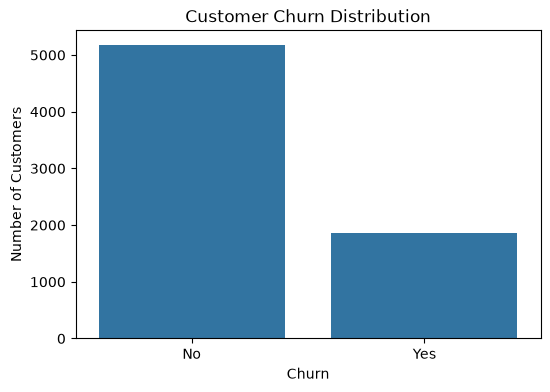

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x=df['Churn'])

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.savefig("../visualizations/churn_distribution.png", bbox_inches="tight")
plt.show()

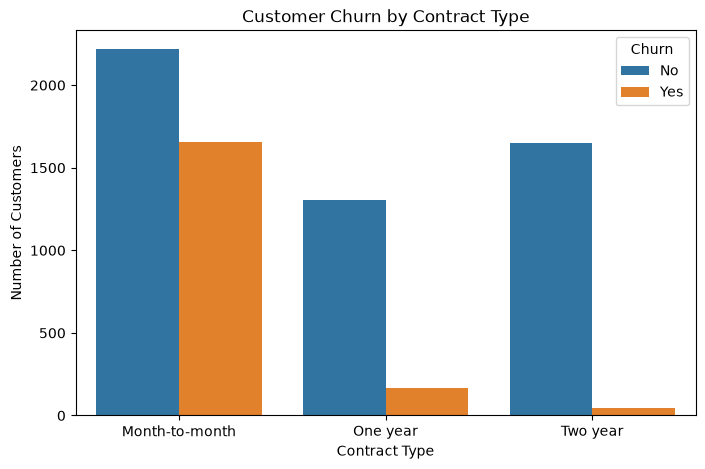

In [202]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.savefig("../visualizations/churn_by_contract.png", bbox_inches="tight")
plt.show()

In [13]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


### Interpretation

The analysis shows that the majority of customers have not churned, while a
smaller proportion have churned.

The difference in the number of churned and retained customers indicates that
the target variable is imbalanced. This is important when developing the
classification model because a model could achieve relatively high accuracy
by predominantly predicting the majority class.

Therefore, model evaluation will not rely on accuracy alone. Precision, recall,
F1-score, confusion matrix, and ROC-AUC will also be considered.

### Business Implication

Customer churn represents a significant business concern because losing
existing customers can reduce recurring revenue and increase the need to
acquire replacement customers.

The objective of the subsequent analysis is therefore to identify the
characteristics and behaviors associated with customers who churn. These
insights will later be used to develop a machine learning model capable of
identifying customers who may be at risk of leaving.

## 2. Customer Churn by Contract Type

Contract type represents the customer's level of commitment to the company.
Customers can have month-to-month, one-year, or two-year contracts.

We investigate whether customer churn varies across these contract types. This
analysis can help determine whether contract structure is associated with
customer retention and potentially identify customers who may require targeted
retention strategies.

In [14]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [15]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [16]:
contract_churn_rate = contract_churn["Yes"].sort_values(ascending=False)

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Yes, dtype: float64

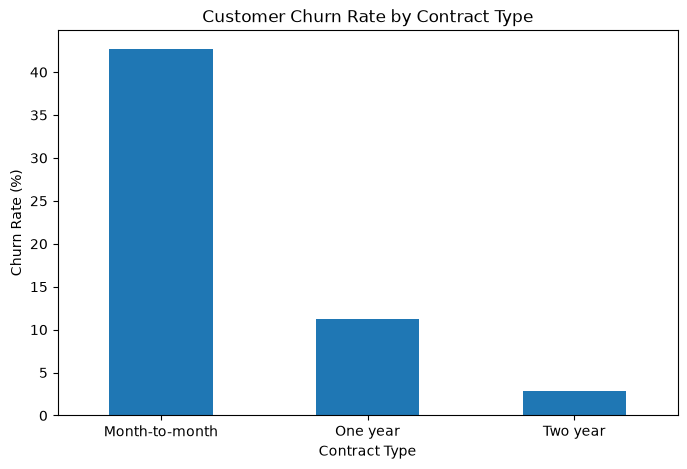

In [17]:
plt.figure(figsize=(8, 5))

contract_churn_rate.plot(kind="bar")

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

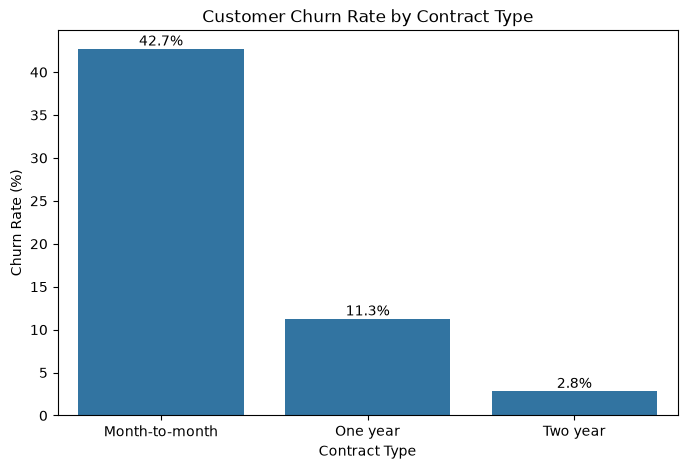

In [18]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=contract_churn_rate.index,
    y=contract_churn_rate.values
)

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [19]:
highest_churn = contract_churn_rate.max()
lowest_churn = contract_churn_rate.min()

difference = highest_churn - lowest_churn

print(f"Highest churn rate: {highest_churn:.2f}%")
print(f"Lowest churn rate: {lowest_churn:.2f}%")
print(f"Difference: {difference:.2f} percentage points")

Highest churn rate: 42.71%
Lowest churn rate: 2.83%
Difference: 39.88 percentage points


### Interpretation

The analysis shows that churn rates differ considerably across contract types.

Customers with month-to-month contracts have the highest churn rate, while
customers with longer-term contracts have substantially lower churn rates.

This suggests that contract type is an important variable to consider when
predicting customer churn.

However, this analysis identifies an association rather than proving that
contract type directly causes customers to churn. Other factors, such as
tenure, monthly charges, and service usage, may also contribute to the observed
relationship.

### Business Implication

The high churn rate among month-to-month customers suggests that this customer
segment may represent an important retention opportunity.

The company could consider targeted retention strategies such as incentives
for longer-term contracts, personalized offers, improved onboarding, or
additional services.

These strategies should be evaluated based on their cost and expected
retention benefit rather than assuming that moving every customer to a
long-term contract will automatically reduce churn.

## 3. Customer Tenure and Churn

Customer tenure represents the number of months a customer has remained with
the company.

We investigate whether the length of the customer relationship is associated
with churn. Understanding this relationship can help identify whether newly
acquired customers represent a higher-risk segment and whether the company
should place greater emphasis on early-stage customer retention.

In [20]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [21]:
df["tenure"].nunique()

73

In [22]:
df["tenure"].unique()[:20]

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30])

In [23]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [24]:
df.groupby("Churn")["tenure"].median()

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

In [25]:
tenure_summary = df.groupby("Churn")["tenure"].agg(
    ["count", "mean", "median", "min", "max"]
)

tenure_summary

,count,mean,median,min,max
Churn,,,,,
No,5174,37.569965,38.0,0,72
Yes,1869,17.979133,10.0,1,72


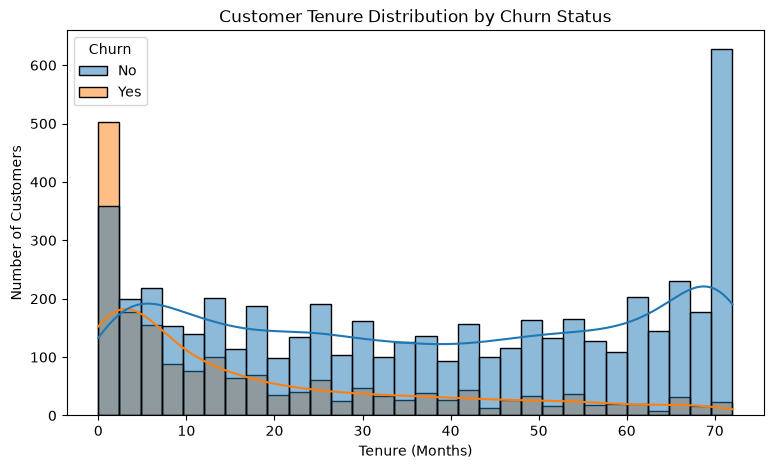

In [26]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

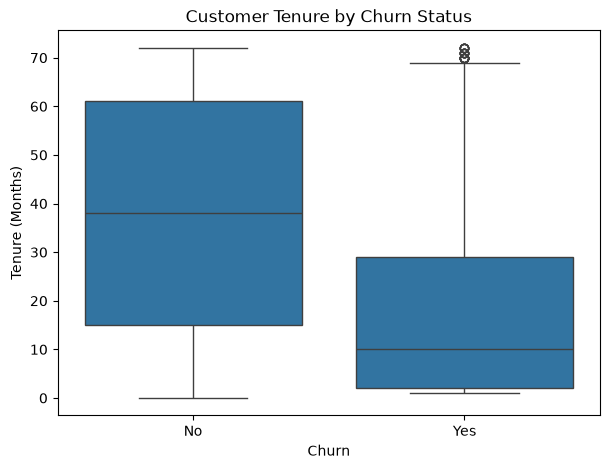

In [201]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.savefig("../visualizations/tenure_vs_churn.png", bbox_inches="tight")
plt.show()

In [28]:
bins = [0, 12, 24, 48, float("inf")]

labels = [
    "0-12 months",
    "13-24 months",
    "25-48 months",
    "49+ months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [29]:
df["TenureGroup"].value_counts().sort_index()

TenureGroup
0-12 months     2186
13-24 months    1024
25-48 months    1594
49+ months      2239
Name: count, dtype: int64

In [30]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49+ months,90.486824,9.513176


In [31]:
tenure_churn_rate = tenure_churn["Yes"]

tenure_churn_rate

TenureGroup
0-12 months     47.438243
13-24 months    28.710938
25-48 months    20.388959
49+ months       9.513176
Name: Yes, dtype: float64

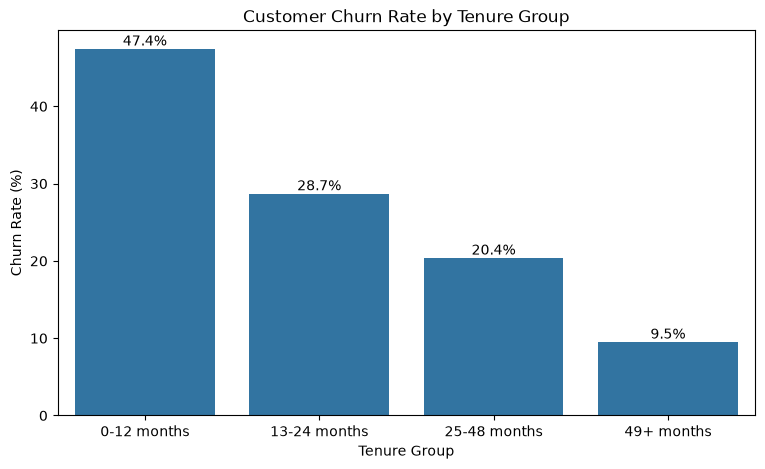

In [32]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=tenure_churn_rate.index,
    y=tenure_churn_rate.values
)

plt.title("Customer Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [33]:
highest_tenure_churn = tenure_churn_rate.max()
lowest_tenure_churn = tenure_churn_rate.min()

tenure_difference = highest_tenure_churn - lowest_tenure_churn

print(f"Highest churn rate: {highest_tenure_churn:.2f}%")
print(f"Lowest churn rate: {lowest_tenure_churn:.2f}%")
print(f"Difference: {tenure_difference:.2f} percentage points")

Highest churn rate: 47.44%
Lowest churn rate: 9.51%
Difference: 37.93 percentage points


### Interpretation

The analysis indicates that customer tenure is associated with churn.

Customers with shorter tenure appear to have a higher likelihood of churning,
while customers who have remained with the company for longer periods tend to
have lower churn rates.

The tenure-group analysis provides additional evidence that the early stages
of the customer relationship may represent an important period for retention.

However, tenure alone does not explain customer churn. Other factors,
including contract type, monthly charges, services, and payment method, may
also contribute to the observed pattern.

### Business Implication

The higher churn observed among newer customers suggests that customer
retention efforts should not begin only after a customer shows signs of
leaving.

The company could focus on the early customer lifecycle through improved
onboarding, early engagement campaigns, proactive customer support, and
personalized offers.

The machine learning model developed later in this project will help determine
whether tenure remains an important predictor of churn when considered
alongside other customer characteristics.

## 4. Monthly Charges and Customer Churn

MonthlyCharges represents the amount a customer is charged each month.

This analysis investigates whether customers with different monthly spending
levels have different churn rates. Understanding this relationship can help
determine whether pricing or perceived value may be associated with customer
retention.

In [34]:
df["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [35]:
df["MonthlyCharges"].nunique()

1585

In [36]:
df["MonthlyCharges"].isnull().sum()

np.int64(0)

In [37]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [38]:
df.groupby("Churn")["MonthlyCharges"].median()

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64

In [39]:
monthly_charges_summary = df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
)

monthly_charges_summary

,count,mean,median,min,max
Churn,,,,,
No,5174,61.265124,64.425,18.25,118.75
Yes,1869,74.441332,79.650,18.85,118.35


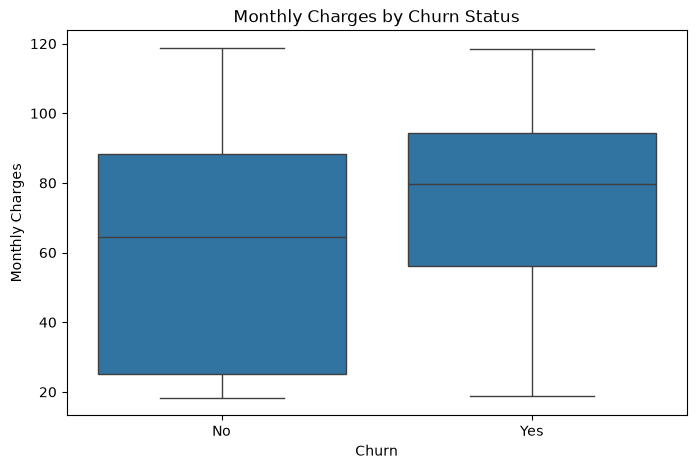

In [203]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.savefig("../visualizations/monthly_charges_vs_churn.png", bbox_inches="tight")
plt.show()

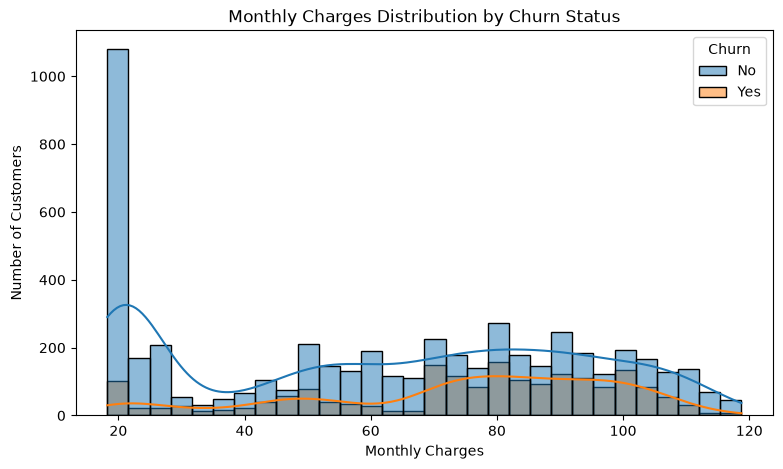

In [41]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

In [42]:
df["MonthlyChargeGroup"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ]
)

In [43]:
df["MonthlyChargeGroup"].value_counts().sort_index()

MonthlyChargeGroup
Low            1762
Medium-Low     1766
Medium-High    1757
High           1758
Name: count, dtype: int64

In [44]:
charge_churn = pd.crosstab(
    df["MonthlyChargeGroup"],
    df["Churn"],
    normalize="index"
) * 100

charge_churn

Churn,No,Yes
MonthlyChargeGroup,,
Low,88.762770,11.237230
Medium-Low,75.424689,24.575311
Medium-High,62.492886,37.507114
High,67.121729,32.878271


In [45]:
charge_churn_rate = charge_churn["Yes"]

charge_churn_rate

MonthlyChargeGroup
Low            11.237230
Medium-Low     24.575311
Medium-High    37.507114
High           32.878271
Name: Yes, dtype: float64

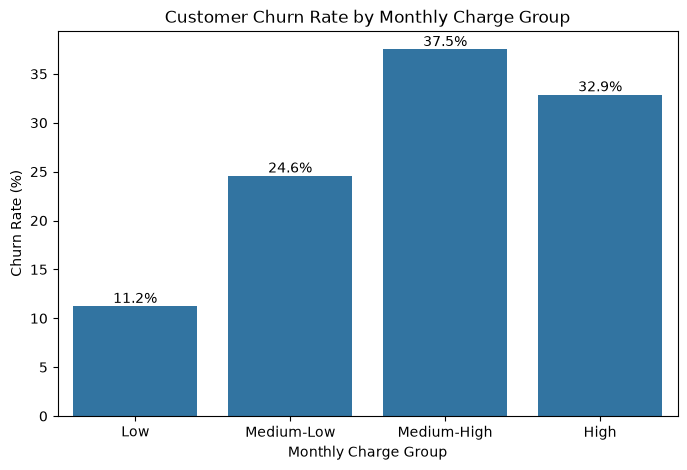

In [46]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=charge_churn_rate.index,
    y=charge_churn_rate.values
)

plt.title("Customer Churn Rate by Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Interpretation

The analysis shows that monthly charges differ between customers who churn
and customers who remain with the company.

The churn-rate analysis across monthly charge groups provides further insight
into whether customers with higher monthly charges are more likely to churn.

If higher-charge groups exhibit higher churn rates, this may indicate that
pricing or perceived value could be associated with customer churn. However,
monthly charges should not be interpreted independently because pricing may
also be related to the services a customer uses and their contract type.

### Business Implication

If customers with higher monthly charges demonstrate elevated churn rates,
the company should investigate whether these customers perceive sufficient
value from the services they receive.

Potential retention strategies could include personalized offers, service
bundling, loyalty incentives, or targeted reviews of high-cost customer
segments.

However, retention decisions should consider the customer's contract type,
tenure, service usage, and overall customer value rather than relying on
monthly charges alone.

In [47]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [48]:
payment_churn_counts = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

payment_churn_counts

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [49]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [50]:
payment_churn_rate = payment_churn["Yes"].sort_values(
    ascending=False
)

payment_churn_rate

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Yes, dtype: float64

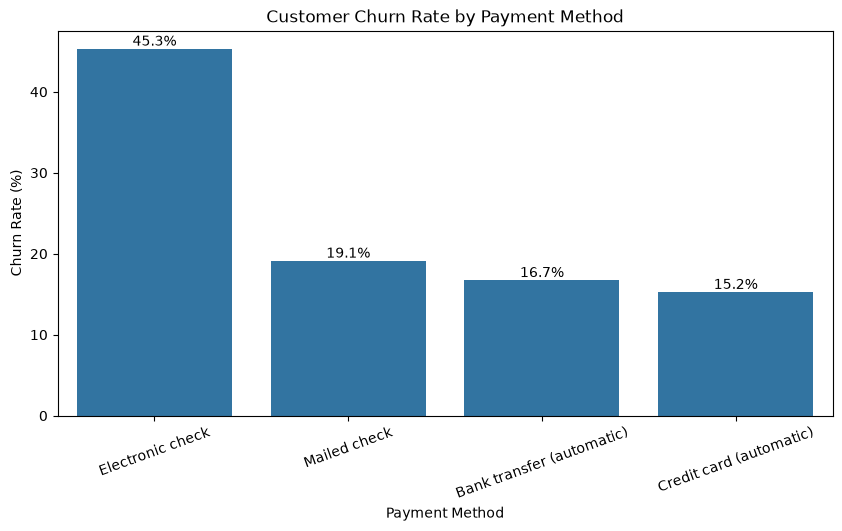

In [204]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=payment_churn_rate.index,
    y=payment_churn_rate.values
)

plt.title("Customer Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.savefig("../visualizations/churn_by_payment_method.png", bbox_inches="tight")
plt.show()

In [52]:
highest_payment_churn = payment_churn_rate.max()
lowest_payment_churn = payment_churn_rate.min()

payment_difference = (
    highest_payment_churn - lowest_payment_churn
)

print(f"Highest churn rate: {highest_payment_churn:.2f}%")
print(f"Lowest churn rate: {lowest_payment_churn:.2f}%")
print(
    f"Difference: {payment_difference:.2f} percentage points"
)

Highest churn rate: 45.29%
Lowest churn rate: 15.24%
Difference: 30.04 percentage points


### Interpretation

The analysis shows that customer churn varies across payment methods.

The payment method with the highest observed churn rate is Electronic checks
while Credit card has the lowest observed churn rate.

This indicates that payment method may be associated with customer churn and
could therefore be a useful variable for the predictive model.

However, this relationship should not automatically be interpreted as
causal. Differences in churn may also be related to other customer
characteristics, such as contract type, tenure, monthly charges, or the
services used by the customer.

In [53]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [54]:
internet_churn_counts = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

internet_churn_counts

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [55]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [56]:
internet_churn_rate = internet_churn["Yes"].sort_values(
    ascending=False
)

internet_churn_rate

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Yes, dtype: float64

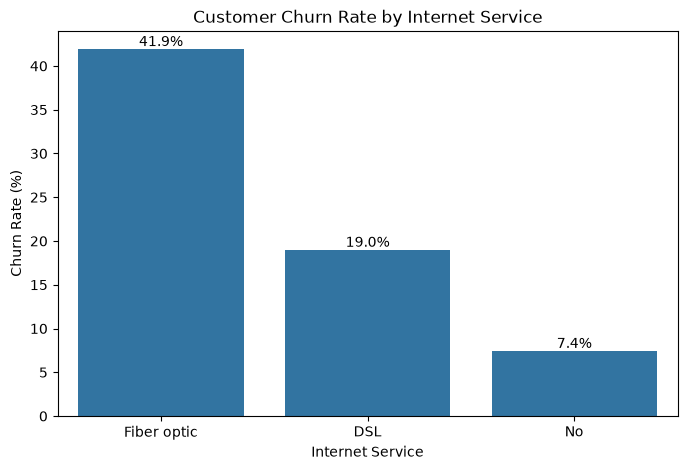

In [57]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=internet_churn_rate.index,
    y=internet_churn_rate.values
)

plt.title("Customer Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [58]:
highest_internet_churn = internet_churn_rate.max()
lowest_internet_churn = internet_churn_rate.min()

internet_difference = (
    highest_internet_churn - lowest_internet_churn
)

print(f"Highest churn rate: {highest_internet_churn:.2f}%")
print(f"Lowest churn rate: {lowest_internet_churn:.2f}%")
print(
    f"Difference: {internet_difference:.2f} percentage points"
)

Highest churn rate: 41.89%
Lowest churn rate: 7.40%
Difference: 34.49 percentage points


### Interpretation

The analysis shows that customer churn varies across internet service types.

The fibre optic category has the highest observed churn rate,
while No internet category has the lowest observed churn rate.

This suggests that internet service type may be associated with customer churn
and could be an important predictor in the machine learning model.

However, this relationship should not be interpreted as evidence that the
internet service itself causes customers to churn. Other factors, including
contract type, tenure, monthly charges, technical support, and additional
services, may also contribute to the observed differences.

### Business Implication

The company should investigate why customers within higher-churn internet
service segments are more likely to leave.

Possible areas of investigation include pricing, service quality, customer
support, perceived value, and the availability of additional services.

Customers in higher-risk service segments could potentially receive more
proactive support, targeted offers, or service reviews.

Internet service type will therefore be retained as a potential predictor for
the churn prediction model.

In [59]:
df["OnlineSecurity"].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [60]:
security_churn_counts = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"]
)

security_churn_counts

Churn,No,Yes
OnlineSecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


In [61]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [62]:
security_churn_rate = security_churn["Yes"].sort_values(
    ascending=False
)

security_churn_rate

OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Yes, dtype: float64

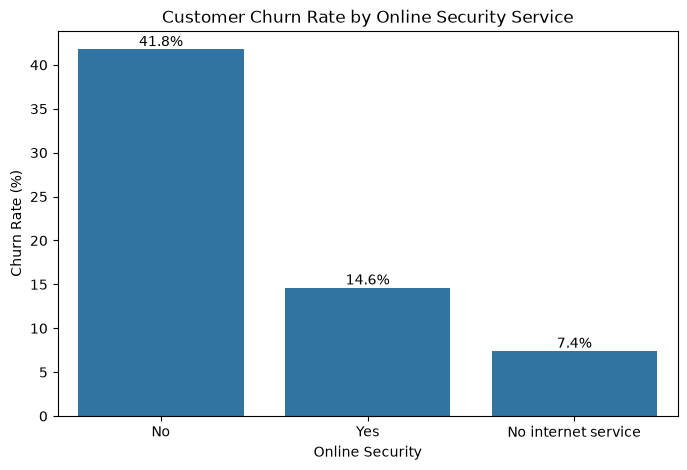

In [63]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=security_churn_rate.index,
    y=security_churn_rate.values
)

plt.title("Customer Churn Rate by Online Security Service")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Interpretation

The analysis indicates that churn rates differ between customers based on
their online security subscription.

Customers in the No online security group have the highest observed churn
rate, while customers in the No internet service group have the lowest.

This suggests that online security subscription status may contain useful
information for predicting churn.

However, the observed relationship does not establish causation. Online
security usage may be related to other customer characteristics such as
contract type, tenure, service adoption, and monthly charges.

### Business Implication

The company should investigate whether customers who do not subscribe to
additional services have lower engagement with the company and consequently
higher churn risk.

Rather than simply encouraging every customer to purchase online security,
the company could use customer-level data to identify customers who may
benefit from additional services or engagement.

Online security status will be retained as a potential predictor for the
machine learning model.

In [64]:
df["TechSupport"].value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [65]:
tech_support_churn_counts = pd.crosstab(
    df["TechSupport"],
    df["Churn"]
)
tech_support_churn_counts

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


In [66]:
tech_support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

tech_support_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [67]:
tech_support_churn_rate = tech_support_churn["Yes"].sort_values(
    ascending=False
)

tech_support_churn_rate

TechSupport
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Yes, dtype: float64

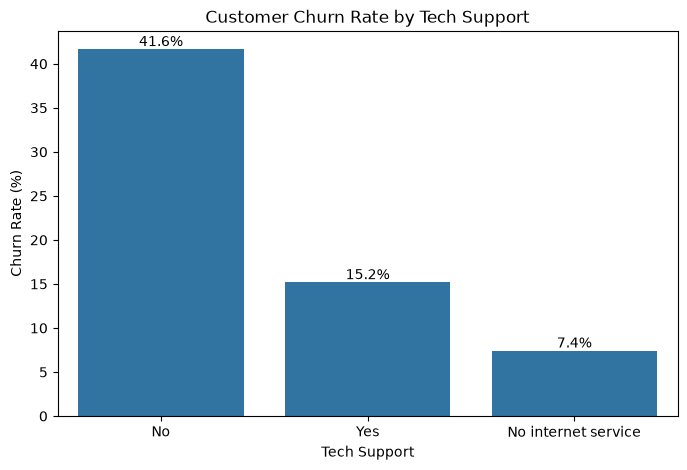

In [68]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=tech_support_churn_rate.index,
    y=tech_support_churn_rate.values
)

plt.title("Customer Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

In [69]:
highest_tech_churn = tech_support_churn_rate.max()
lowest_tech_churn = tech_support_churn_rate.min()

tech_support_difference = (
    highest_tech_churn - lowest_tech_churn
)

print(f"Highest churn rate: {highest_tech_churn:.2f}%")
print(f"Lowest churn rate: {lowest_tech_churn:.2f}%")
print(
    f"Difference: {tech_support_difference:.2f} percentage points"
)

Highest churn rate: 41.64%
Lowest churn rate: 7.40%
Difference: 34.23 percentage points


### Interpretation

The analysis shows that customer churn differs across technical support
subscription categories.

The No Tech Support group has the highest observed churn rate, while
the No internet service group has the lowest.

This suggests that technical support status may contain useful information for
predicting customer churn.

However, the relationship should not be interpreted as causal. Customers who
subscribe to technical support may differ from other customers in terms of
contract type, tenure, internet service, monthly charges, and other service
subscriptions.

### Business Implication

Customers in higher-churn technical-support segments may warrant further
investigation.

The company could examine whether these customers experience unresolved
technical problems, poor service experiences, or insufficient support.

Customer support interactions could also be incorporated into a future churn
prediction system if such data is available.

Tech support status will therefore be retained as a potential predictor for
the machine learning model.

In [70]:
df["OnlineBackup"].value_counts()

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

In [71]:
backup_churn_counts = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"]
)

backup_churn_counts

Churn,No,Yes
OnlineBackup,,
No,1855,1233
No internet service,1413,113
Yes,1906,523


In [72]:
backup_churn = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

backup_churn

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


In [73]:
backup_churn_rate = backup_churn["Yes"].sort_values(
    ascending=False
)

backup_churn_rate

OnlineBackup
No                     39.928756
Yes                    21.531494
No internet service     7.404980
Name: Yes, dtype: float64

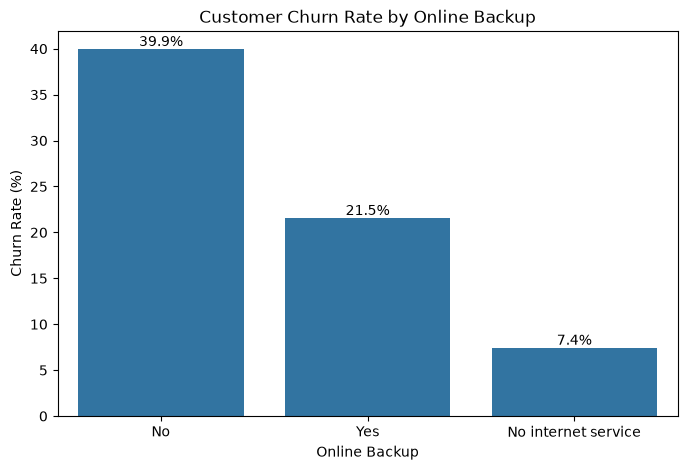

In [74]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=backup_churn_rate.index,
    y=backup_churn_rate.values
)

plt.title("Customer Churn Rate by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Interpretation

The analysis indicates that churn rates vary across online backup
subscription categories.

The No Online Backup group has the highest observed churn rate, while
the No Internet service group has the lowest.

This suggests that online backup status may provide useful information when
predicting customer churn.

However, this relationship may also reflect differences in customer tenure,
contract type, internet service, monthly charges, and overall service
adoption.

### Business Implication

The company should investigate whether customers who use fewer additional
services have lower engagement and consequently higher churn risk.

Instead of treating online backup as an isolated retention solution, the
company could examine the customer's overall service portfolio and identify
customers with low service engagement.

Online backup status will be retained as a potential predictor for the
machine learning model.

In [75]:
df["StreamingTV"].value_counts()

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

In [76]:
streaming_tv_counts = pd.crosstab(
    df["StreamingTV"],
    df["Churn"]
)

streaming_tv_counts

Churn,No,Yes
StreamingTV,,
No,1868,942
No internet service,1413,113
Yes,1893,814


In [77]:
streaming_tv_churn = pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

streaming_tv_churn

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


In [78]:
streaming_tv_churn_rate = streaming_tv_churn["Yes"].sort_values(
    ascending=False
)

streaming_tv_churn_rate

StreamingTV
No                     33.523132
Yes                    30.070188
No internet service     7.404980
Name: Yes, dtype: float64

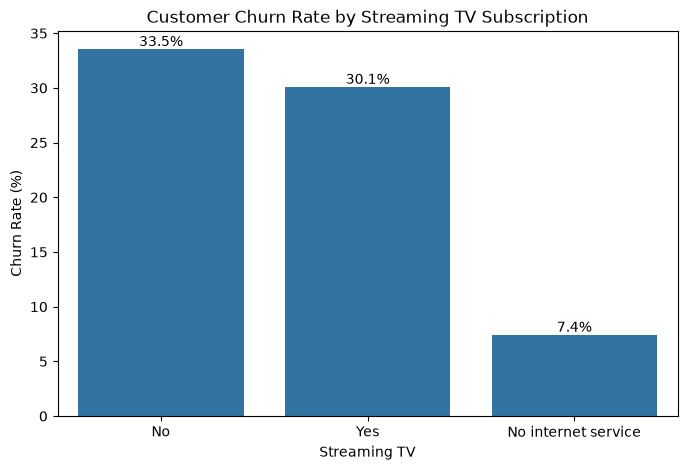

In [79]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=streaming_tv_churn_rate.index,
    y=streaming_tv_churn_rate.values
)

plt.title("Customer Churn Rate by Streaming TV Subscription")
plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Interpretation

The analysis shows that customer churn rates vary across Streaming TV
subscription categories.

The No streaming Tv group has the highest observed churn rate, while
the No internet service group has the lowest.

This suggests that Streaming TV subscription status may contain useful
information for predicting customer churn.

However, Streaming TV should not be interpreted as an independent cause of
churn. Customers who subscribe to Streaming TV may differ from other
customers in terms of contract type, tenure, monthly charges, and other
services.

### Business Implication

The company can use streaming-service adoption as one indicator of customer
engagement.

Customers with limited service adoption could be examined to determine
whether they have lower engagement or perceive less value in the company's
service offering.

Streaming TV subscription status will be retained as a potential predictor
for the churn prediction model.

In [80]:
df["StreamingMovies"].value_counts()

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

In [81]:
streaming_movies_counts = pd.crosstab(
    df["StreamingMovies"],
    df["Churn"]
)

streaming_movies_counts

Churn,No,Yes
StreamingMovies,,
No,1847,938
No internet service,1413,113
Yes,1914,818


In [82]:
streaming_movies_churn = pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

streaming_movies_churn

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


In [83]:
streaming_movies_churn_rate = streaming_movies_churn["Yes"].sort_values(
    ascending=False
)

streaming_movies_churn_rate

StreamingMovies
No                     33.680431
Yes                    29.941435
No internet service     7.404980
Name: Yes, dtype: float64

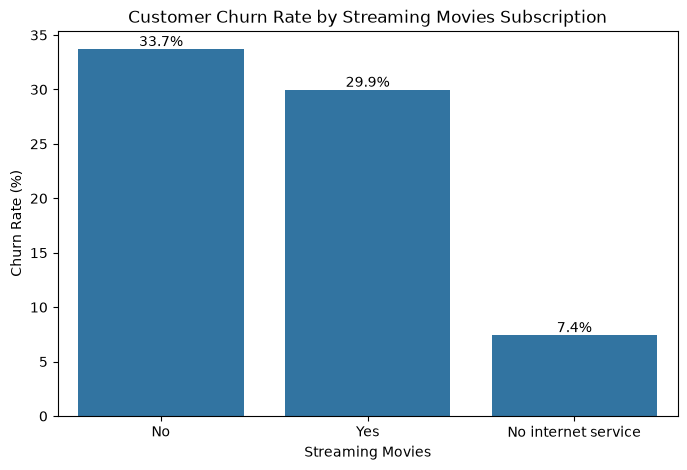

In [84]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=streaming_movies_churn_rate.index,
    y=streaming_movies_churn_rate.values
)

plt.title("Customer Churn Rate by Streaming Movies Subscription")
plt.xlabel("Streaming Movies")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Interpretation

The analysis indicates that churn rates differ across Streaming Movies
subscription categories.

The No Streaming Movies group has the highest observed churn rate, while
the No internet service group has the lowest.

This suggests that Streaming Movies subscription status may provide useful
information for distinguishing customers who churn from those who remain.

However, the observed relationship does not establish causation. Streaming
Movies usage may be associated with other customer characteristics,
including contract type, tenure, internet service, and monthly charges.

### Business Implication

The company should consider customers' overall service adoption when assessing
churn risk.

Rather than targeting customers based on one streaming service alone, the
company could evaluate the customer's complete service profile to determine
whether low engagement is associated with higher churn risk.

Streaming Movies subscription status will therefore be retained as a
potential predictor for the machine learning model.

In [85]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [86]:
df["SeniorCitizenLabel"] = df["SeniorCitizen"].map({
    0: "Non-Senior",
    1: "Senior"
})

In [87]:
df["SeniorCitizenLabel"].value_counts()

SeniorCitizenLabel
Non-Senior    5901
Senior        1142
Name: count, dtype: int64

In [88]:
senior_churn = pd.crosstab(
    df["SeniorCitizenLabel"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizenLabel,,
Non-Senior,76.393832,23.606168
Senior,58.318739,41.681261


In [89]:
senior_churn = pd.crosstab(
    df["SeniorCitizenLabel"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizenLabel,,
Non-Senior,76.393832,23.606168
Senior,58.318739,41.681261


In [90]:
senior_churn_rate = senior_churn["Yes"].sort_values(
    ascending=False
)

senior_churn_rate

SeniorCitizenLabel
Senior        41.681261
Non-Senior    23.606168
Name: Yes, dtype: float64

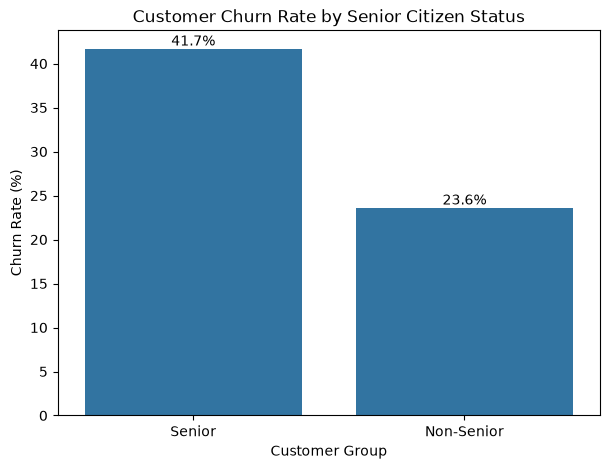

In [91]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=senior_churn_rate.index,
    y=senior_churn_rate.values
)

plt.title("Customer Churn Rate by Senior Citizen Status")
plt.xlabel("Customer Group")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Interpretation

The analysis shows that churn rates differ between senior and non-senior
customers.

The Senior group has the higher observed churn rate.

This indicates that age-related customer segmentation may provide useful
information for churn prediction.

However, demographic characteristics should not be interpreted in isolation.
Differences in contract type, tenure, service usage, and pricing may help
explain the observed relationship.

### Business Implication

If a particular demographic segment demonstrates elevated churn, the company
could investigate whether its products, pricing, customer support, or
communication channels adequately meet the needs of that segment.

Demographic information should be used responsibly as one component of a
broader customer-risk assessment rather than as the sole basis for retention
decisions.

In [92]:
contract_tenure_churn = pd.crosstab(
    [df["Contract"], df["TenureGroup"]],
    df["Churn"],
    normalize="index"
) * 100

contract_tenure_churn

Churn                                No        Yes
Contract       TenureGroup                        
Month-to-month 0-12 months    48.645938  51.354062
               13-24 months   62.279512  37.720488
               25-48 months   67.082294  32.917706
               49+ months     73.976608  26.023392
One year       0-12 months    89.516129  10.483871
               13-24 months   91.878173   8.121827
               25-48 months   89.382239  10.617761
               49+ months     87.066246  12.933754
Two year       0-12 months   100.000000   0.000000
               13-24 months  100.000000   0.000000
               25-48 months   97.810219   2.189781
               49+ months     96.674584   3.325416

In [93]:
contract_tenure_rate = contract_tenure_churn["Yes"].unstack()

contract_tenure_rate

TenureGroup,0-12 months,13-24 months,25-48 months,49+ months
Contract,,,,
Month-to-month,51.354062,37.720488,32.917706,26.023392
One year,10.483871,8.121827,10.617761,12.933754
Two year,0.000000,0.000000,2.189781,3.325416


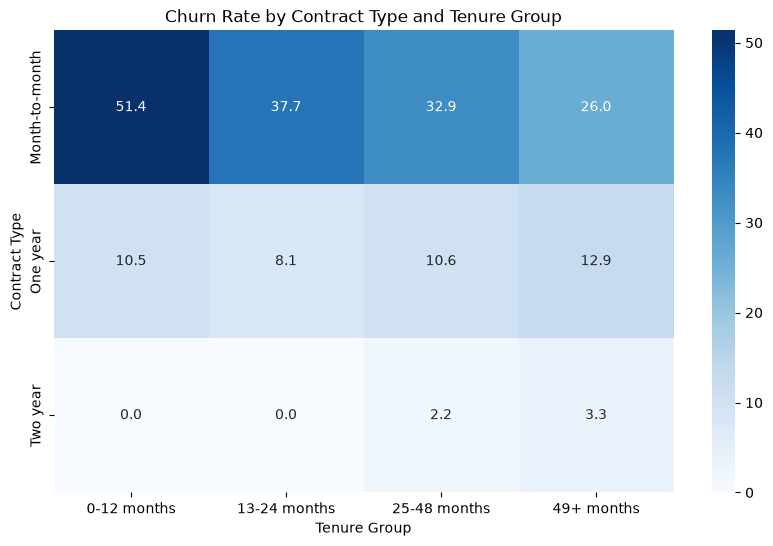

In [94]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    contract_tenure_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Churn Rate by Contract Type and Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Contract Type")

plt.show()

In [95]:
highest_risk_segment = contract_tenure_rate.stack().idxmax()
highest_risk_rate = contract_tenure_rate.stack().max()

print("Highest-risk segment:", highest_risk_segment)
print(f"Churn rate: {highest_risk_rate:.2f}%")

Highest-risk segment: ('Month-to-month', '0-12 months')
Churn rate: 51.35%


### Interpretation

The interaction analysis shows that churn varies across combinations of
contract type and customer tenure.

The highest observed churn rate occurs among customers in the
Month-to-Month contract category and 0-12 Months
tenure group.

This indicates that contract type and tenure may provide complementary
information when identifying customers at risk of churn.

The results suggest that churn risk is not necessarily uniform within a
contract category. Customer tenure may further distinguish higher-risk and
lower-risk customers.

### Business Implication

The company should consider both contract type and customer tenure when
designing retention strategies.

For example, customers in high-risk combinations could receive proactive
engagement, onboarding support, personalized offers, or contract-specific
retention incentives.

This type of segmentation is more actionable than targeting all customers
with the same retention strategy.

In [96]:
contract_charge_churn = pd.crosstab(
    [df["Contract"], df["MonthlyChargeGroup"]],
    df["Churn"],
    normalize="index"
) * 100

contract_charge_churn

Churn                                     No        Yes
Contract       MonthlyChargeGroup                      
Month-to-month Low                 74.965422  25.034578
               Medium-Low          64.382326  35.617674
               Medium-High         46.717818  53.282182
               High                47.816092  52.183908
One year       Low                 96.954315   3.045685
               Medium-Low          91.374663   8.625337
               Medium-High         88.931298  11.068702
               High                79.147982  20.852018
Two year       Low                 99.224806   0.775194
               Medium-Low          97.552448   2.447552
               Medium-High         98.447205   1.552795
               High                92.986425   7.013575

In [97]:
contract_charge_rate = contract_charge_churn["Yes"].unstack()

contract_charge_rate

MonthlyChargeGroup,Low,Medium-Low,Medium-High,High
Contract,,,,
Month-to-month,25.034578,35.617674,53.282182,52.183908
One year,3.045685,8.625337,11.068702,20.852018
Two year,0.775194,2.447552,1.552795,7.013575


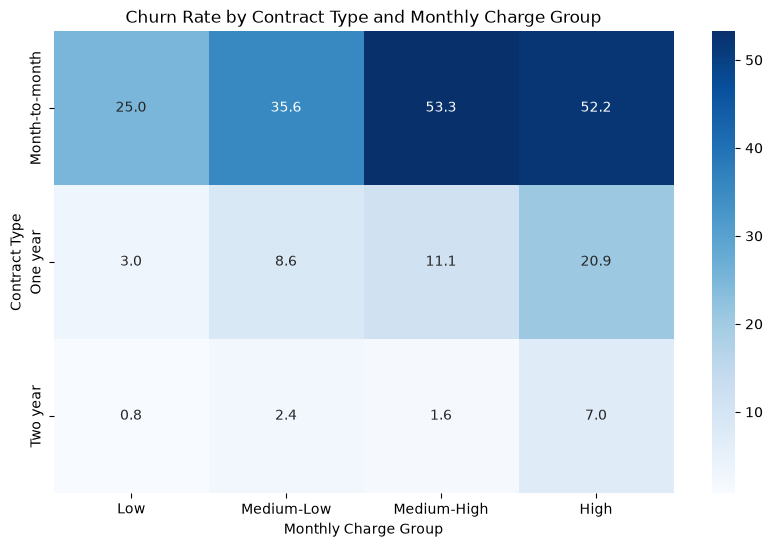

In [98]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    contract_charge_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Churn Rate by Contract Type and Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Contract Type")

plt.show()

In [99]:
highest_charge_segment = contract_charge_rate.stack().idxmax()
highest_charge_rate = contract_charge_rate.stack().max()

print("Highest-risk segment:", highest_charge_segment)
print(f"Churn rate: {highest_charge_rate:.2f}%")

Highest-risk segment: ('Month-to-month', 'Medium-High')
Churn rate: 53.28%


### Interpretation

The analysis shows that churn rates vary across combinations of contract type
and monthly charge group.

The highest observed churn rate occurs within the
Month-to-Month + Medium-High group segment.

This suggests that monthly charges may provide additional information about
churn risk when considered alongside contract type.

However, monthly charges may also reflect the number and type of services a
customer uses. Therefore, this relationship should be examined together with
other customer characteristics.

### Business Implication

High-churn combinations of contract type and monthly charges may represent
important customer segments for retention analysis.

The company could investigate whether customers in these segments perceive
their monthly costs as too high relative to the value they receive.

Potential actions could include personalized pricing reviews, service
bundling, loyalty incentives, or targeted retention offers.

In [100]:
internet_contract_churn = pd.crosstab(
    [df["InternetService"], df["Contract"]],
    df["Churn"],
    normalize="index"
) * 100

internet_contract_churn

Churn                                  No        Yes
InternetService Contract                            
DSL             Month-to-month  67.784137  32.215863
                One year        90.701754   9.298246
                Two year        98.089172   1.910828
Fiber optic     Month-to-month  45.394737  54.605263
                One year        80.705009  19.294991
                Two year        92.773893   7.226107
No              Month-to-month  81.106870  18.893130
                One year        97.527473   2.472527
                Two year        99.216301   0.783699

In [101]:
internet_contract_rate = internet_contract_churn["Yes"].unstack()

internet_contract_rate

Contract,Month-to-month,One year,Two year
InternetService,,,
DSL,32.215863,9.298246,1.910828
Fiber optic,54.605263,19.294991,7.226107
No,18.893130,2.472527,0.783699


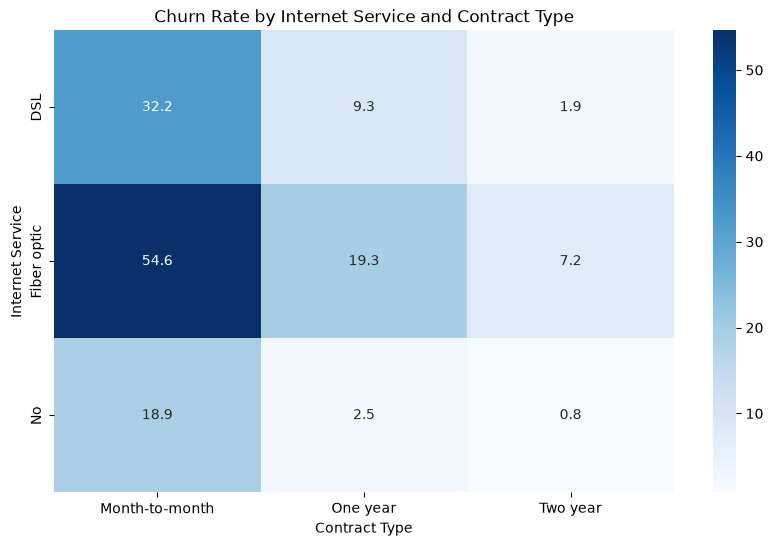

In [102]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    internet_contract_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Churn Rate by Internet Service and Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Internet Service")

plt.show()

In [103]:
highest_internet_contract = internet_contract_rate.stack().idxmax()
highest_internet_contract_rate = internet_contract_rate.stack().max()

print(
    "Highest-risk segment:",
    highest_internet_contract
)

print(
    f"Churn rate: {highest_internet_contract_rate:.2f}%"
)

Highest-risk segment: ('Fiber optic', 'Month-to-month')
Churn rate: 54.61%


### Interpretation

The interaction between internet service and contract type reveals
differences in churn rates across customer segments.

The 'Fiber optic', 'Month-to-month' segment has the highest observed churn rate,
while other combinations demonstrate lower churn.

This indicates that examining internet service and contract type together can
provide additional insight into customer churn compared with examining either
variable independently.

In [104]:
tenure_charge_churn = pd.crosstab(
    [df["TenureGroup"], df["MonthlyChargeGroup"]],
    df["Churn"],
    normalize="index"
) * 100

tenure_charge_rate = tenure_charge_churn["Yes"].unstack()

tenure_charge_rate

MonthlyChargeGroup,Low,Medium-Low,Medium-High,High
TenureGroup,,,,
0-12 months,24.386503,43.607955,66.229508,75.909091
13-24 months,5.797101,22.101449,40.287770,54.123711
25-48 months,4.438642,11.052632,29.123711,34.537246
49+ months,1.330377,5.911330,6.237006,16.981132


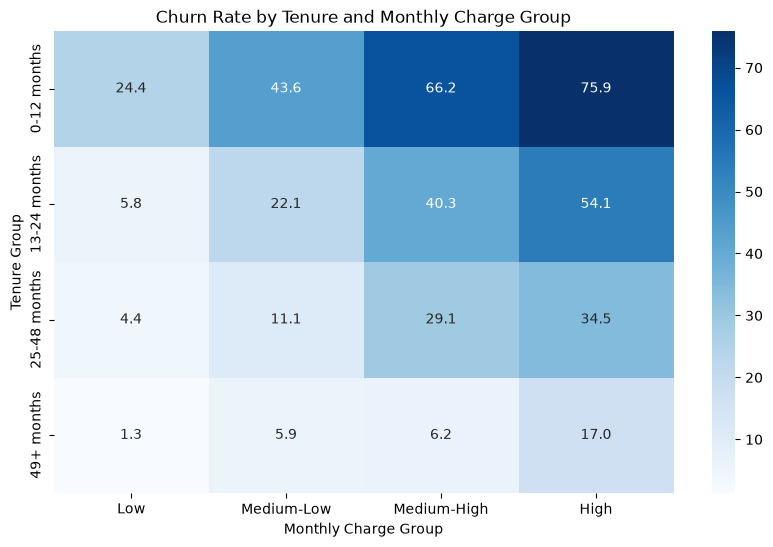

In [105]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    tenure_charge_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Churn Rate by Tenure and Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Tenure Group")

plt.show()

In [106]:
highest_tenure_charge = tenure_charge_rate.stack().idxmax()
highest_tenure_charge_rate = tenure_charge_rate.stack().max()

print(
    "Highest-risk segment:",
    highest_tenure_charge
)

print(
    f"Churn rate: {highest_tenure_charge_rate:.2f}%"
)

Highest-risk segment: ('0-12 months', 'High')
Churn rate: 75.91%


In [107]:
highest_tenure_charge = tenure_charge_rate.stack().idxmax()
highest_tenure_charge_rate = tenure_charge_rate.stack().max()

print(
    "Highest-risk segment:",
    highest_tenure_charge
)

print(
    f"Churn rate: {highest_tenure_charge_rate:.2f}%"
)

Highest-risk segment: ('0-12 months', 'High')
Churn rate: 75.91%


## Interaction Analysis Summary

The interaction analysis demonstrates that customer churn is influenced by
combinations of customer characteristics rather than by individual variables
alone.

Several combinations were examined, including:

- Contract type and tenure
- Contract type and monthly charges
- Internet service and contract type
- Tenure and monthly charges

These analyses help identify customer segments with particularly high
observed churn rates.

The findings suggest that a customer's commitment level, relationship length,
service type, and spending behavior may interact when determining churn risk.

These relationships provide useful business insight and motivate the use of
multiple customer characteristics in the predictive machine learning model.

Importantly, these EDA results represent associations within the dataset and
do not establish causal relationships.

In [108]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [109]:
df["TotalCharges"].value_counts().head()

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
Name: count, dtype: int64

In [110]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [111]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [112]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [113]:
df["TotalCharges"].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

In [114]:
df.isnull().sum().sort_values(ascending=False)

TotalCharges          11
customerID             0
SeniorCitizen          0
gender                 0
Dependents             0
tenure                 0
PhoneService           0
Partner                0
MultipleLines          0
InternetService        0
OnlineBackup           0
OnlineSecurity         0
TechSupport            0
StreamingTV            0
StreamingMovies        0
DeviceProtection       0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
Churn                  0
TenureGroup            0
MonthlyChargeGroup     0
SeniorCitizenLabel     0
dtype: int64

In [115]:
df["ChurnBinary"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [116]:
df["ChurnBinary"].value_counts()

ChurnBinary
0    5174
1    1869
Name: count, dtype: int64

In [117]:
numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen",
    "ChurnBinary"
]

correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,ChurnBinary
tenure,1.000000,0.247900,0.825880,0.016567,-0.352229
MonthlyCharges,0.247900,1.000000,0.651065,0.220173,0.193356
TotalCharges,0.825880,0.651065,1.000000,0.102411,-0.199484
SeniorCitizen,0.016567,0.220173,0.102411,1.000000,0.150889
ChurnBinary,-0.352229,0.193356,-0.199484,0.150889,1.000000


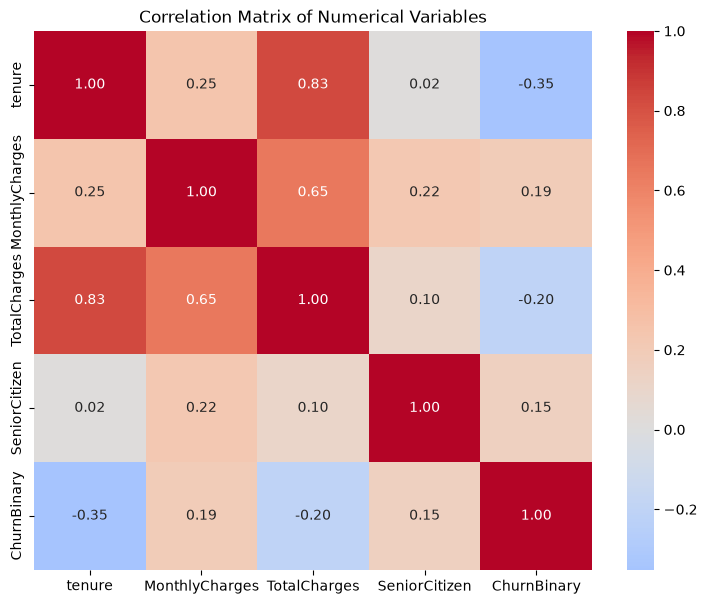

In [118]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [119]:
churn_correlations = (
    correlation_matrix["ChurnBinary"]
    .drop("ChurnBinary")
    .sort_values(ascending=False)
)

churn_correlations

MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229
Name: ChurnBinary, dtype: float64

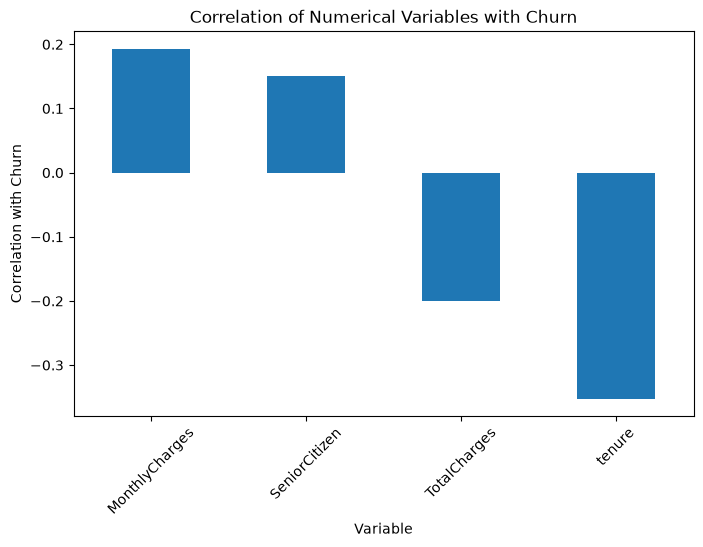

In [120]:
plt.figure(figsize=(8, 5))

churn_correlations.plot(
    kind="bar"
)

plt.title("Correlation of Numerical Variables with Churn")
plt.xlabel("Variable")
plt.ylabel("Correlation with Churn")

plt.xticks(rotation=45)

plt.show()

# 15. Final Exploratory Data Analysis Findings

The exploratory analysis identified several customer characteristics and
service-related variables that appear to be associated with customer churn.

### Key Findings

1. **Contract Type**

   Churn rates differ substantially across contract types, with
   month-to-month customers representing a particularly important
   high-risk segment.

2. **Customer Tenure**

   Customers with shorter tenure generally demonstrate higher churn rates,
   suggesting that the early stages of the customer relationship may be
   particularly important for retention.

3. **Monthly Charges**

   Churn varies across monthly charge groups, indicating that customer
   spending may contain useful information for predicting churn.

4. **Payment Method**

   Churn rates differ across payment methods, suggesting that payment
   behavior may provide additional information about customer risk.

5. **Internet Service**

   Churn varies across internet service categories, making service type a
   potentially useful predictor.

6. **Additional Services**

   Variables such as Online Security, Tech Support, Online Backup, Streaming
   TV, and Streaming Movies show differences in churn across subscription
   categories.

7. **Customer Demographics**

   Demographic characteristics such as senior citizen status may also be
   associated with differences in churn.

8. **Customer Segments**

   Interaction analysis demonstrates that churn risk can vary considerably
   when multiple characteristics are considered together, such as contract
   type, tenure, monthly charges, and internet service.

### Overall Conclusion

The EDA indicates that customer churn is a multifactor problem.

No single variable completely explains why a customer leaves. Instead,
customer commitment, tenure, spending, payment behavior, service type, and
service adoption may collectively contribute to differences in churn risk.

These findings support the development of a supervised machine learning
classification model that uses multiple customer characteristics to estimate
the probability of churn.

In [121]:
df_model = df.copy()

df_model.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,MonthlyChargeGroup,SeniorCitizenLabel,ChurnBinary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 months,Low,Non-Senior,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,25-48 months,Medium-Low,Non-Senior,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 months,Medium-Low,Non-Senior,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 months,Medium-Low,Non-Senior,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 months,Medium-High,Non-Senior,1


In [122]:
 df_model.shape

(7043, 25)

In [123]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   customerID          7043 non-null   str     
 1   gender              7043 non-null   str     
 2   SeniorCitizen       7043 non-null   int64   
 3   Partner             7043 non-null   str     
 4   Dependents          7043 non-null   str     
 5   tenure              7043 non-null   int64   
 6   PhoneService        7043 non-null   str     
 7   MultipleLines       7043 non-null   str     
 8   InternetService     7043 non-null   str     
 9   OnlineSecurity      7043 non-null   str     
 10  OnlineBackup        7043 non-null   str     
 11  DeviceProtection    7043 non-null   str     
 12  TechSupport         7043 non-null   str     
 13  StreamingTV         7043 non-null   str     
 14  StreamingMovies     7043 non-null   str     
 15  Contract            7043 non-null   str     
 16 

In [124]:
df_model.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [125]:
df_model["customerID"].duplicated().sum()

np.int64(0)

In [126]:
df_model.duplicated().sum()

np.int64(0)

In [127]:
df_model["TotalCharges"] = pd.to_numeric(
    df_model["TotalCharges"],
    errors="coerce"
)

In [128]:
df_model["TotalCharges"].isnull().sum()

np.int64(11)

In [129]:
df_model[
    df_model["TotalCharges"].isnull()
][[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [130]:
df_model = df_model.dropna(
    subset=["TotalCharges"]
).copy()

In [131]:
df_model["TotalCharges"].isnull().sum()

np.int64(0)

In [132]:
df_model.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'TenureGroup',
 'MonthlyChargeGroup',
 'SeniorCitizenLabel',
 'ChurnBinary']

In [133]:
eda_columns = [
    "TenureGroup",
    "MonthlyChargeGroup",
    "SeniorCitizenLabel",
    "ChurnBinary"
]

df_model = df_model.drop(
    columns=eda_columns,
    errors="ignore"
)

In [134]:
df_model = df_model.drop(
    columns=["customerID"]
)

In [135]:
df_model.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [136]:
X = df_model.drop(
    columns=["Churn"]
)

y = df_model["Churn"]

In [137]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 19)
Target: (7032,)


In [138]:
y.value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [139]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [140]:
y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [141]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [142]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [143]:
categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [144]:
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [145]:
X[numeric_features].dtypes

tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object

In [146]:
X[categorical_features].dtypes

gender                str
SeniorCitizen       int64
Partner               str
Dependents            str
PhoneService          str
MultipleLines         str
InternetService       str
OnlineSecurity        str
OnlineBackup          str
DeviceProtection      str
TechSupport           str
StreamingTV           str
StreamingMovies       str
Contract              str
PaperlessBilling      str
PaymentMethod         str
dtype: object

In [147]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [148]:
print("Training set:")
print(y_train.value_counts(normalize=True))

print("\nTesting set:")
print(y_test.value_counts(normalize=True))

Training set:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing set:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [149]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [150]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [151]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [152]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [153]:
logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [154]:
y_pred = logistic_pipeline.predict(X_test)

In [155]:
y_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

In [156]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8045


## 17.1 Classification Performance

Accuracy alone is not sufficient for evaluating the churn prediction model
because the dataset contains more customers who did not churn than customers
who churned.

Therefore, we evaluate the model using precision, recall, and F1-score.

- **Precision** measures how many customers predicted to churn actually churned.
- **Recall** measures how many of the customers who actually churned were
  correctly identified by the model.
- **F1-score** provides a balance between precision and recall.

For a customer retention problem, recall is particularly important because
failing to identify a customer who is about to churn may result in a missed
retention opportunity.

In [157]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  ️{accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Accuracy:  ️0.8045
Precision: 0.6495
Recall:    0.5749
F1-Score:  0.6099


In [158]:
baseline_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

baseline_metrics

,Metric,Score
0,Accuracy,0.804549
1,Precision,0.649547
2,Recall,0.574866
3,F1-Score,0.609929


## 17.2 Classification Report

The classification report provides a more detailed view of the model's
performance for both churned and retained customers.

This is useful because the business objective is not simply to classify
customers correctly overall, but to identify customers who are at risk of
churning.

In [159]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## 17.3 Confusion Matrix

A confusion matrix shows the four possible outcomes of a binary
classification model:

- **True Negative (TN):** Customer did not churn and the model correctly
  predicted no churn.
- **True Positive (TP):** Customer churned and the model correctly predicted
  churn.
- **False Positive (FP):** Customer did not churn but the model predicted churn.
- **False Negative (FN):** Customer churned but the model predicted no churn.

For a churn prediction system, false negatives are particularly important
because they represent customers who were actually going to leave but were not
identified by the model.

In [160]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[917, 116],
       [159, 215]])

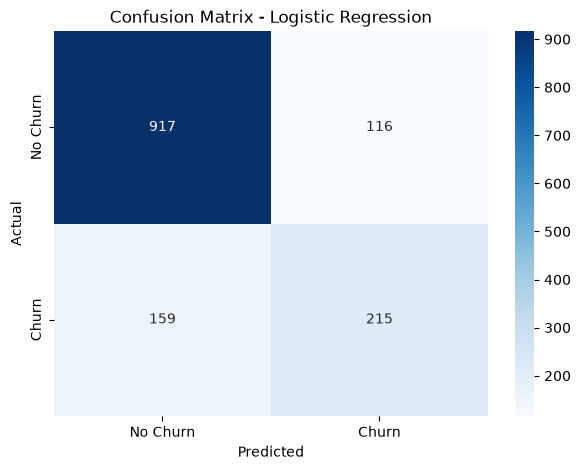

In [161]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [162]:
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

True Negatives:  917
False Positives: 116
False Negatives: 159
True Positives:  215


### Business Interpretation

The confusion matrix allows the company to understand the consequences of
model predictions.

A **false negative** represents a customer who actually churned but was not
identified as high risk. These customers could leave without receiving a
retention intervention.

A **false positive** represents a customer who was identified as high risk but
ultimately did not churn. The company may spend resources attempting to retain
these customers unnecessarily.

Therefore, the appropriate balance between false positives and false
negatives depends on the company's retention strategy and the cost of each
type of mistake.

## 17.5 ROC-AUC Evaluation

The model does not simply produce a churn prediction. It also produces a
probability representing how likely each customer is to churn.

The ROC curve evaluates the model across different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's ability to
distinguish between customers who churn and customers who do not churn.

A higher ROC-AUC indicates better discrimination between the two classes.

## 17.5 ROC-AUC Evaluation

The model does not simply produce a churn prediction. It also produces a
probability representing how likely each customer is to churn.

The ROC curve evaluates the model across different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes the model's ability to
distinguish between customers who churn and customers who do not churn.

A higher ROC-AUC indicates better discrimination between the two classes.

In [163]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8359


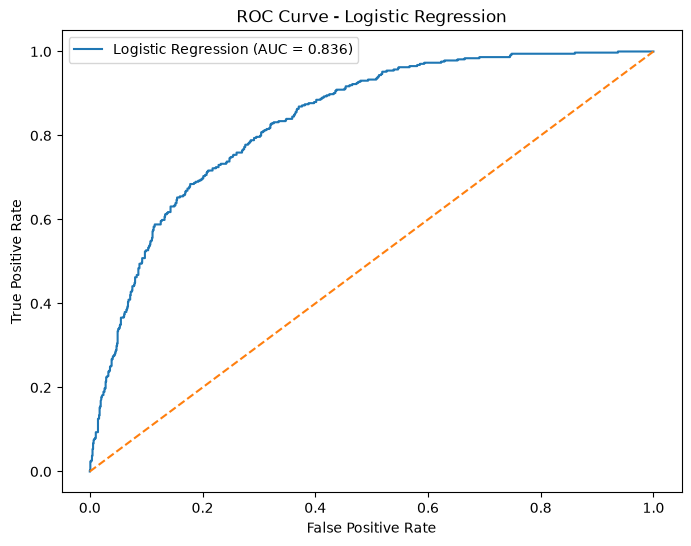

In [164]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

### ROC-AUC Interpretation

The ROC curve demonstrates how the model's true-positive rate changes as the
classification threshold changes.

The ROC-AUC score provides a threshold-independent measure of the model's
ability to distinguish churned customers from retained customers.

This provides additional information beyond accuracy and helps determine
whether the model has useful predictive discrimination.

In [165]:
y_pred = logistic_pipeline.predict(X_test)

In [166]:
y_pred_30 = (y_proba >= 0.30).astype(int)

In [167]:
precision_30 = precision_score(y_test, y_pred_30)
recall_30 = recall_score(y_test, y_pred_30)
f1_30 = f1_score(y_test, y_pred_30)

print(f"Precision: {precision_30:.4f}")
print(f"Recall:    {recall_30:.4f}")
print(f"F1-Score:  {f1_30:.4f}")

Precision: 0.5117
Recall:    0.7594
F1-Score:  0.6114


In [168]:
thresholds_to_test = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

threshold_results = []

for threshold in thresholds_to_test:
    
    predictions = (y_proba >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1-Score": f1_score(
            y_test,
            predictions
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

,Threshold,Precision,Recall,F1-Score
0,0.20,0.457746,0.868984,0.599631
1,0.25,0.483360,0.815508,0.606965
2,0.30,0.511712,0.759358,0.611410
3,0.35,0.544534,0.719251,0.619816
4,0.40,0.579186,0.684492,0.627451
5,0.45,0.603581,0.631016,0.616993
6,0.50,0.649547,0.574866,0.609929
7,0.55,0.667897,0.483957,0.561240
8,0.60,0.680751,0.387701,0.494037


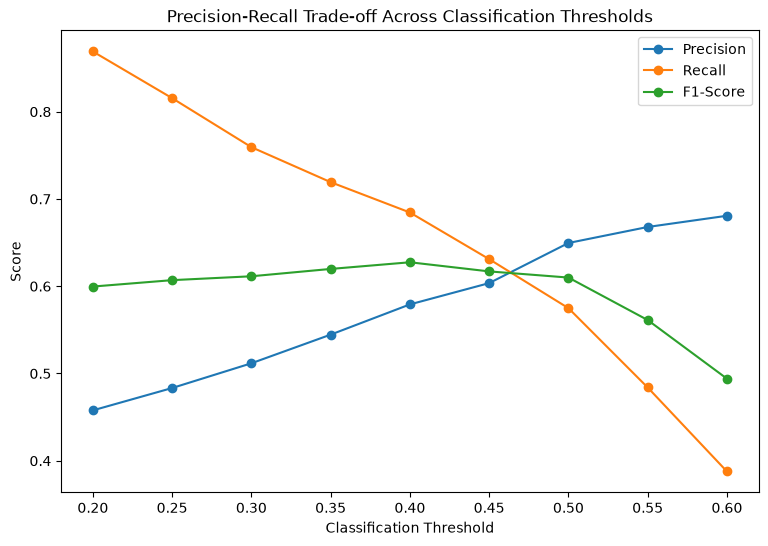

In [169]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.title("Precision-Recall Trade-off Across Classification Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()

plt.show()

## 17.9 Baseline Model Evaluation Summary

The Logistic Regression model provides a baseline for predicting customer
churn.

The evaluation considered accuracy, precision, recall, F1-score, confusion
matrix, and ROC-AUC rather than relying on accuracy alone.

The confusion matrix highlights the number of customers correctly and
incorrectly classified, while the ROC-AUC evaluates the model's ability to
distinguish between churned and retained customers.

The analysis also demonstrates that the classification threshold affects the
trade-off between precision and recall.

From a business perspective, the optimal threshold should depend on the cost
of contacting customers unnecessarily compared with the cost of failing to
identify customers who are likely to churn.

The Logistic Regression model will therefore serve as the baseline against
which more complex models can be compared.

# 18. Random Forest Model

Logistic Regression provides a useful baseline because it is relatively simple
and interpretable.

However, customer churn may depend on nonlinear relationships and interactions
between multiple customer characteristics.

Random Forest is therefore introduced as a second classification model.

Random Forest combines multiple decision trees to make predictions and can
capture nonlinear relationships between customer characteristics and churn.

The model will be trained using the same training and testing datasets used
for Logistic Regression so that the models can be compared fairly.

In [170]:
from sklearn.ensemble import RandomForestClassifier

In [171]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [172]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [173]:
rf_pred = random_forest_pipeline.predict(
    X_test
)

In [174]:
rf_proba = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]

In [175]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_proba
)

print(f"Accuracy:  ️{rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

Accuracy:  ️0.7839
Precision: 0.6151
Recall:    0.5000
F1-Score:  0.5516
ROC-AUC:   0.8158


In [176]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.50      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407



In [177]:
rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

rf_cm

array([[916, 117],
       [187, 187]])

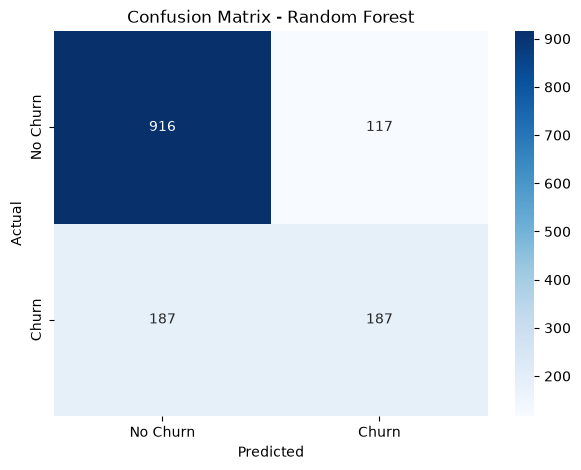

In [178]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [179]:
rf_tn, rf_fp, rf_fn, rf_tp = rf_cm.ravel()

print(f"True Negatives:  {rf_tn}")
print(f"False Positives: {rf_fp}")
print(f"False Negatives: {rf_fn}")
print(f"True Positives:  {rf_tp}")

True Negatives:  916
False Positives: 117
False Negatives: 187
True Positives:  187


In [180]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1-Score": [
        f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.804549,0.649547,0.574866,0.609929,0.835934
1,Random Forest,0.783937,0.615132,0.500000,0.551622,0.815807


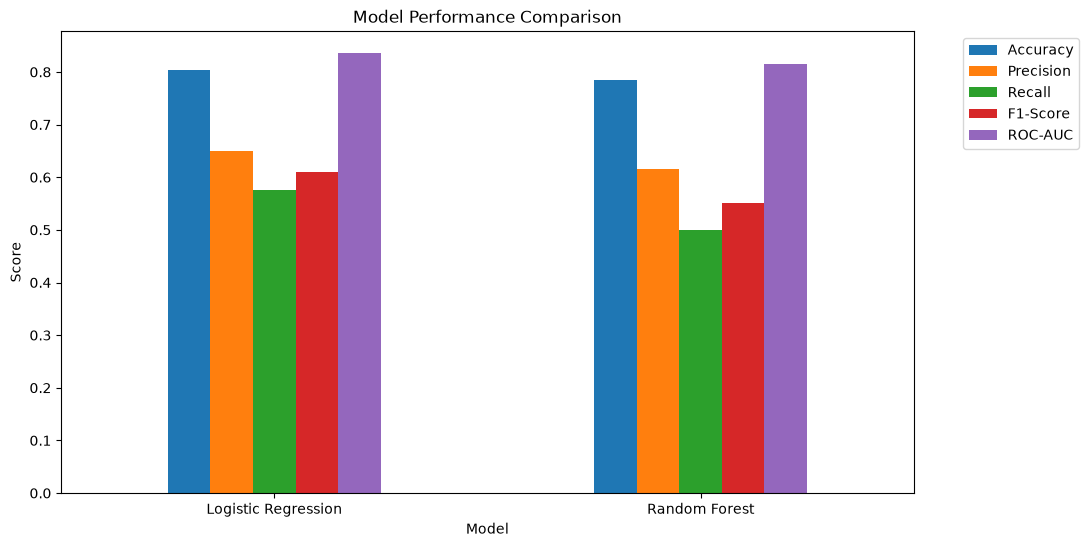

In [181]:
model_comparison.set_index(
    "Model"
)[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

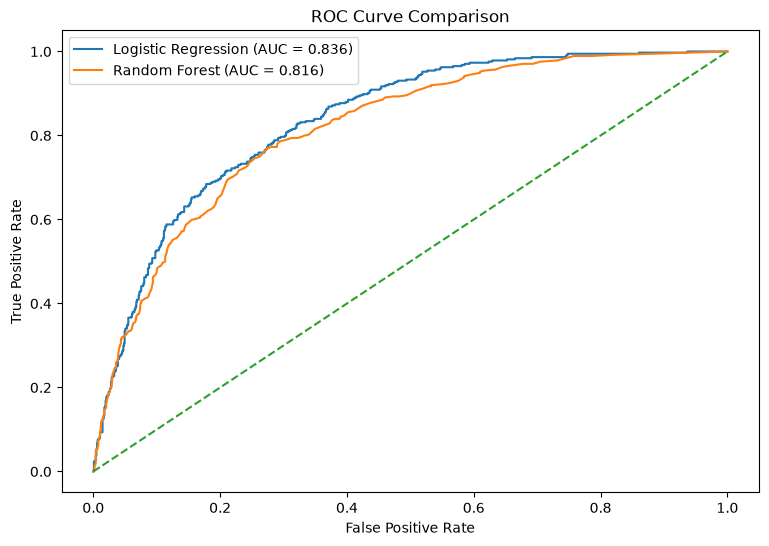

In [205]:
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    y_proba
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_proba
)

plt.figure(figsize=(9, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.savefig("../visualizations/model_roc_curve.png", bbox_inches="tight")
plt.show()

In [183]:
comparison_sorted = model_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

comparison_sorted

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.804549,0.649547,0.574866,0.609929,0.835934
1,Random Forest,0.783937,0.615132,0.500000,0.551622,0.815807


In [184]:
best_model_name = comparison_sorted.iloc[0]["Model"]

print(
    f"Best model based on ROC-AUC: {best_model_name}"
)

Best model based on ROC-AUC: Logistic Regression


## 18.10 Model Comparison Conclusion

Two classification models were developed to predict customer churn:

1. Logistic Regression
2. Random Forest

Logistic Regression was established as the baseline model, while Random Forest
was introduced to capture potentially nonlinear relationships and interactions
between customer characteristics.

Both models were evaluated using accuracy, precision, recall, F1-score,
confusion matrices, and ROC-AUC.

The comparison demonstrates that model selection should not be based solely on
accuracy. Because the business objective is to identify customers who are at
risk of leaving, recall and the number of false negatives are particularly
important.

The model that provides the most appropriate balance between predictive
performance and the business cost of incorrect predictions will be selected for
further optimization.

# 19. Hyperparameter Tuning

The initial model comparison showed that Logistic Regression currently
outperforms Random Forest across all evaluated metrics.

However, the models were trained using their initial hyperparameter settings.
These settings may not represent the best configuration for the dataset.

Hyperparameter tuning will therefore be performed to determine whether model
performance can be improved.

The objective is not simply to maximize accuracy. Because this is a customer
churn problem, particular attention will be given to recall, F1-score, and
ROC-AUC.

The tuned models will subsequently be evaluated on the unseen test set.

In [185]:
from sklearn.model_selection import GridSearchCV

In [186]:
lr_param_grid = {
    "classifier__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],
    "classifier__solver": [
        "liblinear",
        "lbfgs"
    ]
}

In [187]:
lr_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=lr_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [188]:
lr_grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the

In [189]:
print("Best parameters:")
print(lr_grid_search.best_params_)

Best parameters:
{'classifier__C': 100, 'classifier__solver': 'liblinear'}


In [190]:
print(
    f"Best cross-validation ROC-AUC: "
    f"{lr_grid_search.best_score_:.4f}"
)

Best cross-validation ROC-AUC: 0.8462


In [191]:
lr_best_model = lr_grid_search.best_estimator_

In [192]:
lr_tuned_pred = lr_best_model.predict(
    X_test
)

In [193]:
lr_tuned_proba = lr_best_model.predict_proba(
    X_test
)[:, 1]

In [194]:
lr_tuned_accuracy = accuracy_score(
    y_test,
    lr_tuned_pred
)

lr_tuned_precision = precision_score(
    y_test,
    lr_tuned_pred
)

lr_tuned_recall = recall_score(
    y_test,
    lr_tuned_pred
)

lr_tuned_f1 = f1_score(
    y_test,
    lr_tuned_pred
)

lr_tuned_roc_auc = roc_auc_score(
    y_test,
    lr_tuned_proba
)

In [195]:
print(f"Accuracy:  {lr_tuned_accuracy:.4f}")
print(f"Precision: {lr_tuned_precision:.4f}")
print(f"Recall:    {lr_tuned_recall:.4f}")
print(f"F1-Score:  {lr_tuned_f1:.4f}")
print(f"ROC-AUC:   {lr_tuned_roc_auc:.4f}")

Accuracy:  0.7967
Precision: 0.6317
Recall:    0.5642
F1-Score:  0.5960
ROC-AUC:   0.8348


In [196]:
rf_param_grid = {
    "classifier__n_estimators": [
        100,
        200,
        300
    ],
    "classifier__max_depth": [
        None,
        5,
        10,
        20
    ],
    "classifier__min_samples_split": [
        2,
        5,
        10
    ],
    "classifier__min_samples_leaf": [
        1,
        2,
        4
    ]
}

In [197]:
rf_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [198]:
rf_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [199]:
rf_grid_search.fit(
    X_train,
    y_train
)

KeyboardInterrupt: 

In [ ]:
print("Best parameters:")
print(rf_grid_search.best_params_)

Best parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}


In [ ]:
print(
    f"Best cross-validation ROC-AUC: "
    f"{rf_grid_search.best_score_:.4f}"
)

Best cross-validation ROC-AUC: 0.8465


In [ ]:
rf_best_model = rf_grid_search.best_estimator_

In [ ]:
rf_tuned_pred = rf_best_model.predict(
    X_test
)

In [ ]:
rf_tuned_proba = rf_best_model.predict_proba(
    X_test
)[:, 1]

In [ ]:
rf_tuned_accuracy = accuracy_score(
    y_test,
    rf_tuned_pred
)

rf_tuned_precision = precision_score(
    y_test,
    rf_tuned_pred
)

rf_tuned_recall = recall_score(
    y_test,
    rf_tuned_pred
)

rf_tuned_f1 = f1_score(
    y_test,
    rf_tuned_pred
)

rf_tuned_roc_auc = roc_auc_score(
    y_test,
    rf_tuned_proba
)

In [ ]:
print(f"Accuracy:  {rf_tuned_accuracy:.4f}")
print(f"Precision: {rf_tuned_precision:.4f}")
print(f"Recall:    {rf_tuned_recall:.4f}")
print(f"F1-Score:  {rf_tuned_f1:.4f}")
print(f"ROC-AUC:   {rf_tuned_roc_auc:.4f}")

Accuracy:  0.7953
Precision: 0.6453
Recall:    0.5107
F1-Score:  0.5701
ROC-AUC:   0.8349


In [ ]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Logistic Regression",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        lr_tuned_accuracy,
        rf_tuned_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        lr_tuned_precision,
        rf_tuned_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        lr_tuned_recall,
        rf_tuned_recall
    ],
    "F1-Score": [
        f1,
        rf_f1,
        lr_tuned_f1,
        rf_tuned_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        lr_tuned_roc_auc,
        rf_tuned_roc_auc
    ]
})

final_model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.804549,0.649547,0.574866,0.609929,0.835934
1,Random Forest,0.783937,0.615132,0.500000,0.551622,0.815807
2,Tuned Logistic Regression,0.796731,0.631737,0.564171,0.596045,0.834847
3,Tuned Random Forest,0.795309,0.645270,0.510695,0.570149,0.834931


# 20. Model Interpretation

The predictive model can identify customers who are likely to churn, but a
business also needs to understand which customer characteristics contribute
to those predictions.

Because Logistic Regression provides coefficients for each feature, we can
inspect these coefficients to understand the direction and relative strength
of the model's relationships with customer churn.

Positive coefficients indicate that a feature is associated with a higher
predicted probability of churn, while negative coefficients indicate an
association with a lower predicted probability of churn.

These relationships should be interpreted as model associations rather than
proof of causation.

In [ ]:
feature_names = logistic_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

len(feature_names)

46

In [ ]:
coefficients = logistic_pipeline.named_steps[
    "classifier"
].coef_[0]

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [ ]:
feature_importance.sort_values(
    by="Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient
2,num__TotalCharges,0.642862
37,cat__Contract_Month-to-month,0.624313
17,cat__InternetService_Fiber optic,0.591880
33,cat__StreamingTV_Yes,0.197986
44,cat__PaymentMethod_Electronic check,0.188409
36,cat__StreamingMovies_Yes,0.183854
19,cat__OnlineSecurity_No,0.173613
28,cat__TechSupport_No,0.150621
15,cat__MultipleLines_Yes,0.093474
22,cat__OnlineBackup_No,0.052494


In [ ]:
feature_importance.sort_values(
    by="Coefficient",
    ascending=True
).head(15)

,Feature,Coefficient
0,num__tenure,-1.350384
39,cat__Contract_Two year,-0.772380
16,cat__InternetService_DSL,-0.602034
1,num__MonthlyCharges,-0.530297
40,cat__PaperlessBilling_No,-0.286453
13,cat__MultipleLines_No,-0.284063
20,cat__OnlineSecurity_No internet service,-0.272794
23,cat__OnlineBackup_No internet service,-0.272794
26,cat__DeviceProtection_No internet service,-0.272794
35,cat__StreamingMovies_No internet service,-0.272794


In [ ]:
feature_importance["AbsoluteCoefficient"] = (
    feature_importance["Coefficient"].abs()
)

In [ ]:
top_features = feature_importance.sort_values(
    by="AbsoluteCoefficient",
    ascending=False
).head(20)

top_features

,Feature,Coefficient,AbsoluteCoefficient
0,num__tenure,-1.350384,1.350384
39,cat__Contract_Two year,-0.772380,0.772380
2,num__TotalCharges,0.642862,0.642862
37,cat__Contract_Month-to-month,0.624313,0.624313
16,cat__InternetService_DSL,-0.602034,0.602034
17,cat__InternetService_Fiber optic,0.591880,0.591880
1,num__MonthlyCharges,-0.530297,0.530297
40,cat__PaperlessBilling_No,-0.286453,0.286453
13,cat__MultipleLines_No,-0.284063,0.284063
26,cat__DeviceProtection_No internet service,-0.272794,0.272794


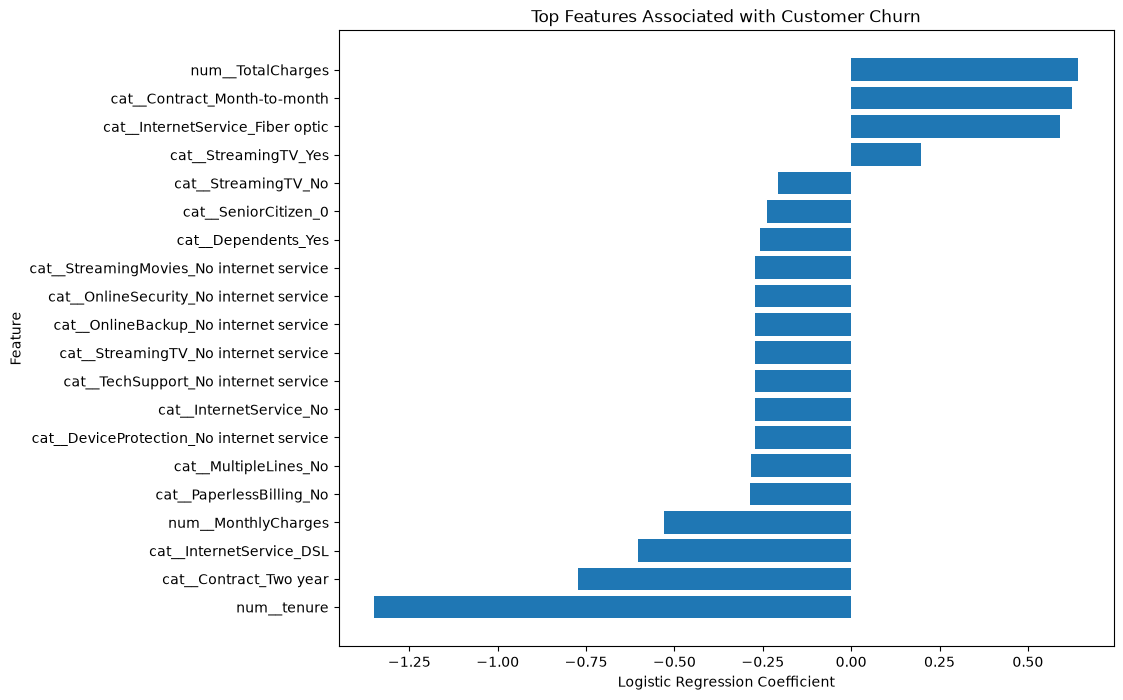

In [ ]:
plt.figure(figsize=(10, 8))

top_features_sorted = top_features.sort_values(
    by="Coefficient"
)

plt.barh(
    top_features_sorted["Feature"],
    top_features_sorted["Coefficient"]
)

plt.title(
    "Top Features Associated with Customer Churn"
)

plt.xlabel(
    "Logistic Regression Coefficient"
)

plt.ylabel(
    "Feature"
)

plt.show()

In [ ]:
high_churn_features = (
    feature_importance[
        feature_importance["Coefficient"] > 0
    ]
    .sort_values(
        by="Coefficient",
        ascending=False
    )
    .head(10)
)

high_churn_features

,Feature,Coefficient,AbsoluteCoefficient
2,num__TotalCharges,0.642862,0.642862
37,cat__Contract_Month-to-month,0.624313,0.624313
17,cat__InternetService_Fiber optic,0.591880,0.591880
33,cat__StreamingTV_Yes,0.197986,0.197986
44,cat__PaymentMethod_Electronic check,0.188409,0.188409
36,cat__StreamingMovies_Yes,0.183854,0.183854
19,cat__OnlineSecurity_No,0.173613,0.173613
28,cat__TechSupport_No,0.150621,0.150621
15,cat__MultipleLines_Yes,0.093474,0.093474
22,cat__OnlineBackup_No,0.052494,0.052494


In [ ]:
low_churn_features = (
    feature_importance[
        feature_importance["Coefficient"] < 0
    ]
    .sort_values(
        by="Coefficient",
        ascending=True
    )
    .head(10)
)

low_churn_features

,Feature,Coefficient,AbsoluteCoefficient
0,num__tenure,-1.350384,1.350384
39,cat__Contract_Two year,-0.772380,0.772380
16,cat__InternetService_DSL,-0.602034,0.602034
1,num__MonthlyCharges,-0.530297,0.530297
40,cat__PaperlessBilling_No,-0.286453,0.286453
13,cat__MultipleLines_No,-0.284063,0.284063
18,cat__InternetService_No,-0.272794,0.272794
20,cat__OnlineSecurity_No internet service,-0.272794,0.272794
26,cat__DeviceProtection_No internet service,-0.272794,0.272794
29,cat__TechSupport_No internet service,-0.272794,0.272794


In [ ]:
high_churn_features

,Feature,Coefficient,AbsoluteCoefficient
2,num__TotalCharges,0.642862,0.642862
37,cat__Contract_Month-to-month,0.624313,0.624313
17,cat__InternetService_Fiber optic,0.591880,0.591880
33,cat__StreamingTV_Yes,0.197986,0.197986
44,cat__PaymentMethod_Electronic check,0.188409,0.188409
36,cat__StreamingMovies_Yes,0.183854,0.183854
19,cat__OnlineSecurity_No,0.173613,0.173613
28,cat__TechSupport_No,0.150621,0.150621
15,cat__MultipleLines_Yes,0.093474,0.093474
22,cat__OnlineBackup_No,0.052494,0.052494


In [ ]:
low_churn_features

,Feature,Coefficient,AbsoluteCoefficient
0,num__tenure,-1.350384,1.350384
39,cat__Contract_Two year,-0.772380,0.772380
16,cat__InternetService_DSL,-0.602034,0.602034
1,num__MonthlyCharges,-0.530297,0.530297
40,cat__PaperlessBilling_No,-0.286453,0.286453
13,cat__MultipleLines_No,-0.284063,0.284063
18,cat__InternetService_No,-0.272794,0.272794
20,cat__OnlineSecurity_No internet service,-0.272794,0.272794
26,cat__DeviceProtection_No internet service,-0.272794,0.272794
29,cat__TechSupport_No internet service,-0.272794,0.272794


# 21. Customer-Level Churn Prediction

The selected Logistic Regression model can generate a probability of churn for
each customer.

Instead of producing only a binary prediction of "Churn" or "No Churn", the
model provides a probability that can be used to rank customers according to
their estimated churn risk.

This allows the business to prioritize retention efforts toward customers who
are most likely to leave.

The probability should be interpreted as a model-generated risk score rather
than a guarantee that a customer will churn.

In [ ]:
customer_predictions = pd.DataFrame({
    "CustomerID": df.loc[X_test.index, "customerID"],
    "ActualChurn": y_test,
    "ChurnProbability": y_proba,
    "PredictedChurn": y_pred
})

customer_predictions.head()

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn
974,0604-THJFP,0,0.017588,0
619,4059-IIEBK,0,0.591095,1
4289,2228-BZDEE,0,0.004822,0
3721,2839-RFSQE,1,0.201749,0
4533,5360-LJCNJ,0,0.101160,0


In [ ]:
customer_predictions["ChurnProbabilityPercent"] = (
    customer_predictions["ChurnProbability"] * 100
)

In [ ]:
customer_predictions.head()

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn,ChurnProbabilityPercent
974,0604-THJFP,0,0.017588,0,1.758819
619,4059-IIEBK,0,0.591095,1,59.109537
4289,2228-BZDEE,0,0.004822,0,0.482176
3721,2839-RFSQE,1,0.201749,0,20.174909
4533,5360-LJCNJ,0,0.101160,0,10.116014


In [ ]:
def assign_risk_level(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

In [ ]:
customer_predictions["RiskLevel"] = (
    customer_predictions["ChurnProbability"]
    .apply(assign_risk_level)
)

In [ ]:
customer_predictions["RiskLevel"] = (
    customer_predictions["ChurnProbability"]
    .apply(assign_risk_level)
)

In [ ]:
customer_predictions.head(10)

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn,ChurnProbabilityPercent,RiskLevel
974,0604-THJFP,0,0.017588,0,1.758819,Low Risk
619,4059-IIEBK,0,0.591095,1,59.109537,Medium Risk
4289,2228-BZDEE,0,0.004822,0,0.482176,Low Risk
3721,2839-RFSQE,1,0.201749,0,20.174909,Low Risk
4533,5360-LJCNJ,0,0.101160,0,10.116014,Low Risk
445,7752-XUSCI,1,0.471588,0,47.158795,Medium Risk
5898,8277-RVRSV,0,0.026531,0,2.653108,Low Risk
3387,3530-CRZSB,0,0.165561,0,16.556066,Low Risk
1346,2845-HSJCY,1,0.678443,1,67.844341,Medium Risk
5690,0336-KXKFK,0,0.015466,0,1.546643,Low Risk


In [ ]:
risk_counts = (
    customer_predictions["RiskLevel"]
    .value_counts()
    .reindex([
        "High Risk",
        "Medium Risk",
        "Low Risk"
    ])
)

risk_counts

RiskLevel
High Risk       83
Medium Risk    359
Low Risk       965
Name: count, dtype: int64

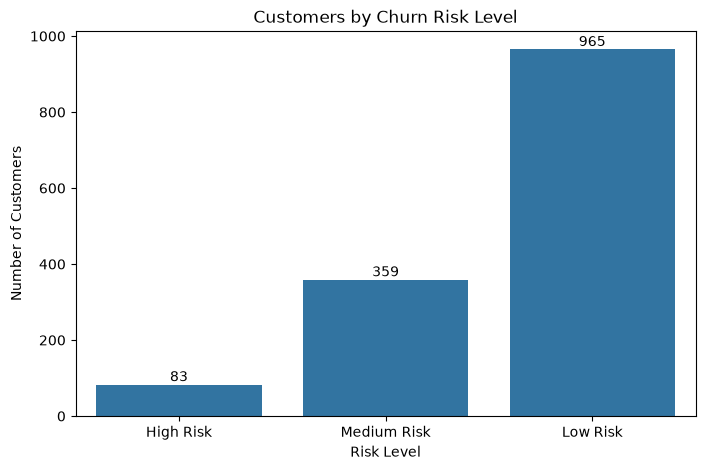

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Customers by Churn Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
high_risk_customers = (
    customer_predictions[
        customer_predictions["RiskLevel"] == "High Risk"
    ]
    .sort_values(
        by="ChurnProbability",
        ascending=False
    )
)

high_risk_customers.head(20)

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn,ChurnProbabilityPercent,RiskLevel
3380,5178-LMXOP,1,0.847785,1,84.778526,High Risk
3159,5150-ITWWB,0,0.846030,1,84.602988,High Risk
2631,6861-XWTWQ,1,0.826737,1,82.673691,High Risk
4585,1069-XAIEM,1,0.822542,1,82.254189,High Risk
3727,9057-SIHCH,1,0.816013,1,81.601336,High Risk
2797,6023-YEBUP,1,0.815629,1,81.562892,High Risk
582,2865-TCHJW,1,0.815326,1,81.532563,High Risk
933,4750-ZRXIU,1,0.810647,1,81.064688,High Risk
6240,6521-YYTYI,1,0.793281,1,79.328140,High Risk
2516,8245-UMPYT,1,0.792023,1,79.202317,High Risk


In [ ]:
customer_details = df.loc[
    customer_predictions.index
].copy()

In [ ]:
customer_details["ChurnProbability"] = (
    customer_predictions["ChurnProbability"]
)

customer_details["RiskLevel"] = (
    customer_predictions["RiskLevel"]
)

customer_details["PredictedChurn"] = (
    customer_predictions["PredictedChurn"]
)

In [ ]:
high_risk_customer_details = (
    customer_details[
        customer_details["RiskLevel"] == "High Risk"
    ]
    .sort_values(
        by="ChurnProbability",
        ascending=False
    )
)

In [ ]:
high_risk_customer_details[
    [
        "customerID",
        "gender",
        "SeniorCitizen",
        "tenure",
        "InternetService",
        "Contract",
        "PaymentMethod",
        "MonthlyCharges",
        "TotalCharges",
        "ChurnProbability",
        "RiskLevel"
    ]
].head(20)

,customerID,gender,SeniorCitizen,tenure,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,ChurnProbability,RiskLevel
3380,5178-LMXOP,Male,1,1,Fiber optic,Month-to-month,Electronic check,95.10,95.10,0.847785,High Risk
3159,5150-ITWWB,Male,1,3,Fiber optic,Month-to-month,Electronic check,94.85,335.75,0.846030,High Risk
2631,6861-XWTWQ,Male,1,7,Fiber optic,Month-to-month,Electronic check,99.25,665.45,0.826737,High Risk
4585,1069-XAIEM,Female,1,1,Fiber optic,Month-to-month,Electronic check,85.05,85.05,0.822542,High Risk
3727,9057-SIHCH,Female,0,3,Fiber optic,Month-to-month,Electronic check,96.60,291.90,0.816013,High Risk
2797,6023-YEBUP,Male,0,3,Fiber optic,Month-to-month,Electronic check,100.95,329.95,0.815629,High Risk
582,2865-TCHJW,Female,1,4,Fiber optic,Month-to-month,Electronic check,89.20,346.20,0.815326,High Risk
933,4750-ZRXIU,Female,1,4,Fiber optic,Month-to-month,Electronic check,84.60,360.10,0.810647,High Risk
6240,6521-YYTYI,Male,0,1,Fiber optic,Month-to-month,Electronic check,93.30,93.30,0.793281,High Risk
2516,8245-UMPYT,Female,1,16,Fiber optic,Month-to-month,Electronic check,96.40,1581.20,0.792023,High Risk


In [ ]:
number_high_risk = (
    customer_predictions["RiskLevel"]
    .eq("High Risk")
    .sum()
)

total_customers = len(customer_predictions)

high_risk_percentage = (
    number_high_risk / total_customers * 100
)

print(f"High-risk customers: {number_high_risk}")
print(f"Percentage of test customers: {high_risk_percentage:.2f}%")

High-risk customers: 83
Percentage of test customers: 5.90%


In [ ]:
customer_risk_ranking = (
    customer_predictions
    .sort_values(
        by="ChurnProbability",
        ascending=False
    )
    .reset_index(drop=True)
)

In [ ]:
customer_risk_ranking["RiskRank"] = (
    customer_risk_ranking.index + 1
)

In [ ]:
customer_risk_ranking[
    [
        "RiskRank",
        "CustomerID",
        "ChurnProbability",
        "RiskLevel",
        "ActualChurn"
    ]
].head(20)

,RiskRank,CustomerID,ChurnProbability,RiskLevel,ActualChurn
0,1,5178-LMXOP,0.847785,High Risk,1
1,2,5150-ITWWB,0.846030,High Risk,0
2,3,6861-XWTWQ,0.826737,High Risk,1
3,4,1069-XAIEM,0.822542,High Risk,1
4,5,9057-SIHCH,0.816013,High Risk,1
5,6,6023-YEBUP,0.815629,High Risk,1
6,7,2865-TCHJW,0.815326,High Risk,1
7,8,4750-ZRXIU,0.810647,High Risk,1
8,9,6521-YYTYI,0.793281,High Risk,1
9,10,8245-UMPYT,0.792023,High Risk,1


In [ ]:
high_risk_customer_details[
    "Contract"
].value_counts()

Contract
Month-to-month    83
Name: count, dtype: int64

In [ ]:
high_risk_customer_details[
    "Contract"
].value_counts()

Contract
Month-to-month    83
Name: count, dtype: int64

In [ ]:
high_risk_customer_details[
    "PaymentMethod"
].value_counts()

PaymentMethod
Electronic check             73
Bank transfer (automatic)     4
Credit card (automatic)       4
Mailed check                  2
Name: count, dtype: int64

In [ ]:
high_risk_customer_details[
    "tenure"
].describe()

count    83.000000
mean      6.433735
std       5.825078
min       1.000000
25%       2.000000
50%       4.000000
75%       9.000000
max      26.000000
Name: tenure, dtype: float64

In [ ]:
high_risk_customer_details[
    "MonthlyCharges"
].describe()

count     83.000000
mean      84.142771
std       17.048795
min       25.200000
25%       75.800000
50%       87.050000
75%       95.125000
max      106.700000
Name: MonthlyCharges, dtype: float64

In [ ]:
overall_contract = (
    df.loc[X_test.index, "Contract"]
    .value_counts(normalize=True)
    * 100
)

high_risk_contract = (
    high_risk_customer_details["Contract"]
    .value_counts(normalize=True)
    * 100
)

contract_comparison = pd.DataFrame({
    "Overall Test Population (%)": overall_contract,
    "High-Risk Customers (%)": high_risk_contract
})

contract_comparison

,Overall Test Population (%),High-Risk Customers (%)
Contract,,
Month-to-month,56.147832,100.0
One year,20.611230,NaN
Two year,23.240938,NaN


## 21.11 From Prediction to Retention Action

The purpose of the churn model is not simply to predict which customers may
leave. The predictions should support targeted retention decisions.

Customers can be prioritized according to their predicted churn probability
and relevant customer characteristics.

Potential retention strategies include:

- High-risk customers: proactive retention outreach and personalized offers.
- Medium-risk customers: targeted engagement and monitoring.
- Low-risk customers: maintain normal service and engagement.

The specific intervention should depend on the customer's characteristics,
business value, and the reason for their potential churn.

The model should therefore be treated as a decision-support tool rather than
an automatic decision-making system.

# 21. Threshold Optimization

The default classification threshold of 0.50 is not necessarily optimal for a
customer retention problem.

A lower threshold can identify more customers who may be at risk of churn,
which can increase recall. However, this may also increase the number of
customers incorrectly identified as high risk.

The appropriate threshold therefore depends on the business trade-off between
missing potential churners and spending retention resources on customers who
ultimately remain.

Multiple thresholds will be evaluated using precision, recall, and F1-score.

In [ ]:
thresholds_to_test = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
]

threshold_results = []

for threshold in thresholds_to_test:

    predictions = (
        y_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1-Score": f1_score(
            y_test,
            predictions
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

,Threshold,Precision,Recall,F1-Score
0,0.20,0.457746,0.868984,0.599631
1,0.25,0.483360,0.815508,0.606965
2,0.30,0.511712,0.759358,0.611410
3,0.35,0.544534,0.719251,0.619816
4,0.40,0.579186,0.684492,0.627451
5,0.45,0.603581,0.631016,0.616993
6,0.50,0.649547,0.574866,0.609929
7,0.55,0.667897,0.483957,0.561240
8,0.60,0.680751,0.387701,0.494037
9,0.65,0.694805,0.286096,0.405303


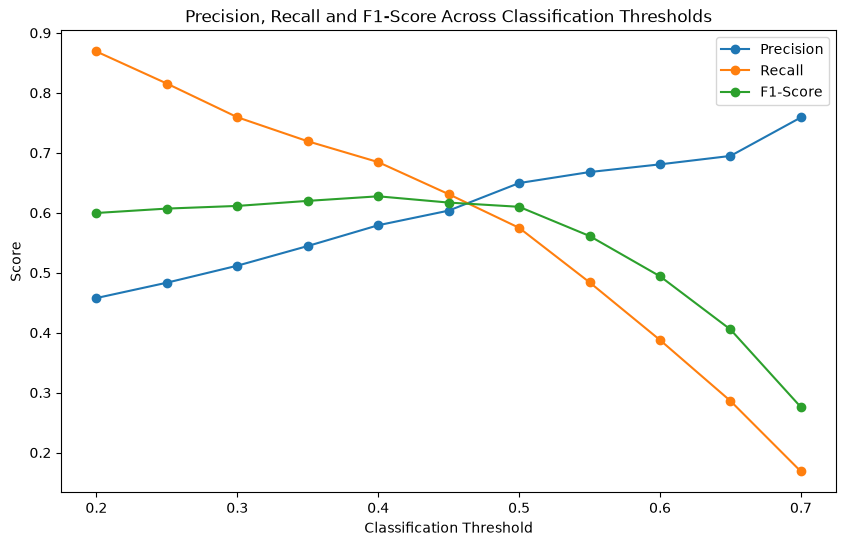

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.title(
    "Precision, Recall and F1-Score Across Classification Thresholds"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.legend()

plt.show()

In [ ]:
best_f1_row = threshold_results.loc[
    threshold_results["F1-Score"].idxmax()
]

best_f1_row

Threshold    0.400000
Precision    0.579186
Recall       0.684492
F1-Score     0.627451
Name: 4, dtype: float64

In [ ]:
print(
    f"Best F1 threshold: "
    f"{best_f1_row['Threshold']:.2f}"
)

print(
    f"Precision: "
    f"{best_f1_row['Precision']:.4f}"
)

print(
    f"Recall: "
    f"{best_f1_row['Recall']:.4f}"
)

print(
    f"F1-Score: "
    f"{best_f1_row['F1-Score']:.4f}"
)

Best F1 threshold: 0.40
Precision: 0.5792
Recall: 0.6845
F1-Score: 0.6275


In [ ]:
threshold_results["FlaggedCustomers"] = [
    (y_proba >= threshold).sum()
    for threshold in threshold_results["Threshold"]
]

threshold_results

,Threshold,Precision,Recall,F1-Score,FlaggedCustomers
0,0.20,0.457746,0.868984,0.599631,710
1,0.25,0.483360,0.815508,0.606965,631
2,0.30,0.511712,0.759358,0.611410,555
3,0.35,0.544534,0.719251,0.619816,494
4,0.40,0.579186,0.684492,0.627451,442
5,0.45,0.603581,0.631016,0.616993,391
6,0.50,0.649547,0.574866,0.609929,331
7,0.55,0.667897,0.483957,0.561240,271
8,0.60,0.680751,0.387701,0.494037,213
9,0.65,0.694805,0.286096,0.405303,154


In [ ]:
high_recall_thresholds = threshold_results[
    threshold_results["Recall"] >= 0.65
]

high_recall_thresholds

,Threshold,Precision,Recall,F1-Score,FlaggedCustomers
0,0.20,0.457746,0.868984,0.599631,710
1,0.25,0.483360,0.815508,0.606965,631
2,0.30,0.511712,0.759358,0.611410,555
3,0.35,0.544534,0.719251,0.619816,494
4,0.40,0.579186,0.684492,0.627451,442


In [ ]:
if not high_recall_thresholds.empty:

    recommended_threshold = (
        high_recall_thresholds
        .sort_values(
            by="Precision",
            ascending=False
        )
        .iloc[0]["Threshold"]
    )

else:

    recommended_threshold = (
        best_f1_row["Threshold"]
    )

print(
    f"Recommended working threshold: "
    f"{recommended_threshold:.2f}"
)

Recommended working threshold: 0.40


# 22. Customer Risk Segmentation

The selected classification threshold is now applied to the customer churn
probabilities.

This converts model probabilities into actionable customer risk categories.

The resulting dataset can be used to prioritize customers for retention
interventions.

In [ ]:
selected_threshold = recommended_threshold

In [ ]:
customer_predictions["PredictedChurn_SelectedThreshold"] = (
    customer_predictions["ChurnProbability"]
    >= selected_threshold
).astype(int)

In [ ]:
def assign_risk_level(probability):

    if probability >= 0.70:
        return "High Risk"

    elif probability >= selected_threshold:
        return "Medium Risk"

    else:
        return "Low Risk"

In [ ]:
customer_predictions["RiskLevel"] = (
    customer_predictions["ChurnProbability"]
    .apply(assign_risk_level)
)

In [ ]:
customer_predictions.head(10)

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn,ChurnProbabilityPercent,RiskLevel,PredictedChurn_SelectedThreshold
974,0604-THJFP,0,0.017588,0,1.758819,Low Risk,0
619,4059-IIEBK,0,0.591095,1,59.109537,Medium Risk,1
4289,2228-BZDEE,0,0.004822,0,0.482176,Low Risk,0
3721,2839-RFSQE,1,0.201749,0,20.174909,Low Risk,0
4533,5360-LJCNJ,0,0.101160,0,10.116014,Low Risk,0
445,7752-XUSCI,1,0.471588,0,47.158795,Medium Risk,1
5898,8277-RVRSV,0,0.026531,0,2.653108,Low Risk,0
3387,3530-CRZSB,0,0.165561,0,16.556066,Low Risk,0
1346,2845-HSJCY,1,0.678443,1,67.844341,Medium Risk,1
5690,0336-KXKFK,0,0.015466,0,1.546643,Low Risk,0


In [ ]:
customer_risk_table = customer_predictions[
    [
        "CustomerID",
        "ChurnProbability",
        "ChurnProbabilityPercent",
        "PredictedChurn_SelectedThreshold",
        "RiskLevel",
        "ActualChurn"
    ]
].copy()

In [ ]:
customer_risk_table = (
    customer_risk_table
    .sort_values(
        by="ChurnProbability",
        ascending=False
    )
    .reset_index(drop=True)
)

In [ ]:
customer_risk_table.head(20)

,CustomerID,ChurnProbability,ChurnProbabilityPercent,PredictedChurn_SelectedThreshold,RiskLevel,ActualChurn
0,5178-LMXOP,0.847785,84.778526,1,High Risk,1
1,5150-ITWWB,0.846030,84.602988,1,High Risk,0
2,6861-XWTWQ,0.826737,82.673691,1,High Risk,1
3,1069-XAIEM,0.822542,82.254189,1,High Risk,1
4,9057-SIHCH,0.816013,81.601336,1,High Risk,1
5,6023-YEBUP,0.815629,81.562892,1,High Risk,1
6,2865-TCHJW,0.815326,81.532563,1,High Risk,1
7,4750-ZRXIU,0.810647,81.064688,1,High Risk,1
8,6521-YYTYI,0.793281,79.328140,1,High Risk,1
9,8245-UMPYT,0.792023,79.202317,1,High Risk,1


In [ ]:
risk_distribution = (
    customer_risk_table["RiskLevel"]
    .value_counts()
    .reindex([
        "High Risk",
        "Medium Risk",
        "Low Risk"
    ])
)

risk_distribution

RiskLevel
High Risk       83
Medium Risk    359
Low Risk       965
Name: count, dtype: int64

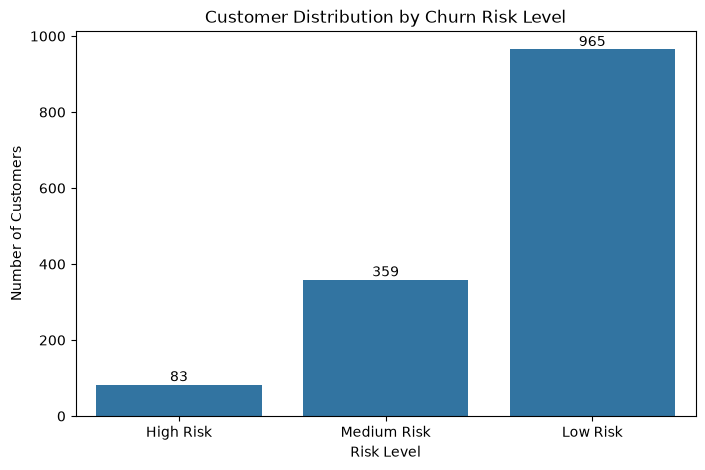

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=risk_distribution.index,
    y=risk_distribution.values
)

plt.title(
    "Customer Distribution by Churn Risk Level"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
customer_risk_table["RetentionPriorityScore"] = (
    customer_risk_table["ChurnProbability"]
    * customer_risk_table["MonthlyCharges"]
)

In [ ]:
priority_customers = (
    customer_risk_table
    .sort_values(
        by="RetentionPriorityScore",
        ascending=False
    )
)

In [ ]:
priority_customers.head(20)

,customerID,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,TotalCharges,ChurnProbability,ChurnProbabilityPercent,RiskLevel,PredictedChurn,RetentionPriorityScore
2797,6023-YEBUP,3,Month-to-month,Fiber optic,Electronic check,100.95,329.95,0.815629,81.562892,High Risk,1,82.337740
2631,6861-XWTWQ,7,Month-to-month,Fiber optic,Electronic check,99.25,665.45,0.826737,82.673691,High Risk,1,82.053638
2448,9221-OTIVJ,14,Month-to-month,Fiber optic,Electronic check,104.85,1531.40,0.778445,77.844504,High Risk,1,81.619963
3956,4587-VVTOX,6,Month-to-month,Fiber optic,Electronic check,105.30,545.20,0.766921,76.692061,High Risk,1,80.756740
3380,5178-LMXOP,1,Month-to-month,Fiber optic,Electronic check,95.10,95.10,0.847785,84.778526,High Risk,1,80.624378
3159,5150-ITWWB,3,Month-to-month,Fiber optic,Electronic check,94.85,335.75,0.846030,84.602988,High Risk,1,80.245934
6839,4078-SAYYN,11,Month-to-month,Fiber optic,Electronic check,100.75,1129.75,0.785907,78.590728,High Risk,1,79.180159
3727,9057-SIHCH,3,Month-to-month,Fiber optic,Electronic check,96.60,291.90,0.816013,81.601336,High Risk,1,78.826890
2294,2027-FECZV,12,Month-to-month,Fiber optic,Electronic check,106.70,1253.90,0.738151,73.815097,High Risk,1,78.760708
4701,5956-YHHRX,21,Month-to-month,Fiber optic,Electronic check,104.35,2271.85,0.743701,74.370067,High Risk,1,77.605164


## 22.6 Recommended Retention Framework

The churn model can support a risk-based retention strategy.

### High Risk

Customers with very high predicted churn probability should receive the
highest priority for proactive intervention.

Potential actions include:

- Personalized retention offers
- Proactive customer-service outreach
- Investigation of service problems
- Contract/value-plan review
- Targeted loyalty incentives

### Medium Risk

These customers may receive lower-cost engagement strategies such as:

- Customer satisfaction surveys
- Product education
- Service recommendations
- Personalized communication
- Monitoring for increasing risk

### Low Risk

Low-risk customers generally require normal customer engagement rather than
expensive retention interventions.

The objective is to allocate limited retention resources according to
predicted risk rather than treating every customer identically.

In [ ]:
threshold_results

,Threshold,Precision,Recall,F1-Score,FlaggedCustomers
0,0.20,0.457746,0.868984,0.599631,710
1,0.25,0.483360,0.815508,0.606965,631
2,0.30,0.511712,0.759358,0.611410,555
3,0.35,0.544534,0.719251,0.619816,494
4,0.40,0.579186,0.684492,0.627451,442
5,0.45,0.603581,0.631016,0.616993,391
6,0.50,0.649547,0.574866,0.609929,331
7,0.55,0.667897,0.483957,0.561240,271
8,0.60,0.680751,0.387701,0.494037,213
9,0.65,0.694805,0.286096,0.405303,154


In [ ]:
best_f1_row

Threshold    0.400000
Precision    0.579186
Recall       0.684492
F1-Score     0.627451
Name: 4, dtype: float64

In [ ]:
recommended_threshold

np.float64(0.4)

In [ ]:
selected_threshold = 0.40

print(f"Selected classification threshold: {selected_threshold:.2f}")

Selected classification threshold: 0.40


In [ ]:
final_predictions = (
    y_proba >= selected_threshold
).astype(int)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print(f"Accuracy:  {accuracy_score(y_test, final_predictions):.4f}")
print(f"Precision: {precision_score(y_test, final_predictions):.4f}")
print(f"Recall:    {recall_score(y_test, final_predictions):.4f}")
print(f"F1-Score:  {f1_score(y_test, final_predictions):.4f}")

Accuracy:  0.7839
Precision: 0.5792
Recall:    0.6845
F1-Score:  0.6275


# 23. Customer Risk Segmentation

The final Logistic Regression model produces a churn probability for each
customer.

A classification threshold of 0.40 was selected based on threshold analysis.
This threshold produced the highest F1-score among the evaluated thresholds
while maintaining a recall of approximately 68.4%.

Customers are therefore classified according to their predicted probability of
churn. This enables the business to prioritize customers for potential
retention interventions.

In [ ]:
customer_predictions = pd.DataFrame({
    "CustomerID": df.loc[X_test.index, "customerID"],
    "ActualChurn": y_test,
    "ChurnProbability": y_proba,
    "PredictedChurn": final_predictions
})

In [ ]:
customer_predictions["ChurnProbabilityPercent"] = (
    customer_predictions["ChurnProbability"] * 100
)

In [ ]:
def assign_risk_level(probability):

    if probability >= 0.70:
        return "High Risk"

    elif probability >= selected_threshold:
        return "Medium Risk"

    else:
        return "Low Risk"

In [ ]:
customer_predictions["RiskLevel"] = (
    customer_predictions["ChurnProbability"]
    .apply(assign_risk_level)
)

In [ ]:
customer_predictions.head(10)

,CustomerID,ActualChurn,ChurnProbability,PredictedChurn,ChurnProbabilityPercent,RiskLevel
974,0604-THJFP,0,0.017588,0,1.758819,Low Risk
619,4059-IIEBK,0,0.591095,1,59.109537,Medium Risk
4289,2228-BZDEE,0,0.004822,0,0.482176,Low Risk
3721,2839-RFSQE,1,0.201749,0,20.174909,Low Risk
4533,5360-LJCNJ,0,0.101160,0,10.116014,Low Risk
445,7752-XUSCI,1,0.471588,1,47.158795,Medium Risk
5898,8277-RVRSV,0,0.026531,0,2.653108,Low Risk
3387,3530-CRZSB,0,0.165561,0,16.556066,Low Risk
1346,2845-HSJCY,1,0.678443,1,67.844341,Medium Risk
5690,0336-KXKFK,0,0.015466,0,1.546643,Low Risk


In [ ]:
risk_distribution = (
    customer_predictions["RiskLevel"]
    .value_counts()
    .reindex([
        "High Risk",
        "Medium Risk",
        "Low Risk"
    ])
)

risk_distribution

RiskLevel
High Risk       83
Medium Risk    359
Low Risk       965
Name: count, dtype: int64

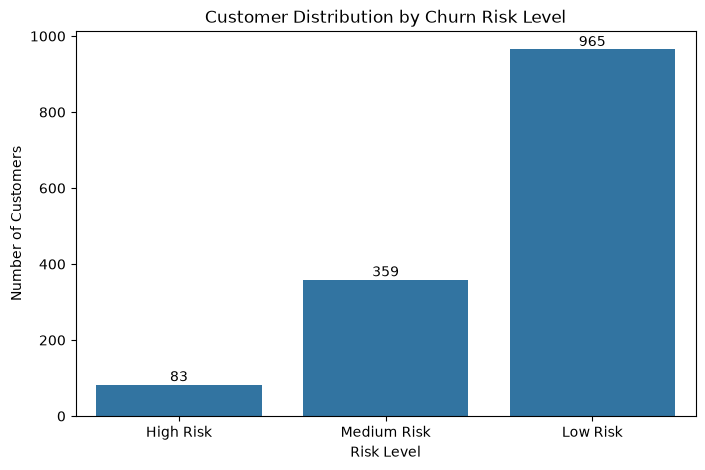

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=risk_distribution.index,
    y=risk_distribution.values
)

plt.title("Customer Distribution by Churn Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
customer_risk_table = df.loc[
    X_test.index,
    [
        "customerID",
        "tenure",
        "Contract",
        "InternetService",
        "PaymentMethod",
        "MonthlyCharges",
        "TotalCharges"
    ]
].copy()

In [ ]:
customer_risk_table["ChurnProbability"] = (
    customer_predictions["ChurnProbability"]
)

customer_risk_table["ChurnProbabilityPercent"] = (
    customer_predictions["ChurnProbabilityPercent"]
)

customer_risk_table["RiskLevel"] = (
    customer_predictions["RiskLevel"]
)

customer_risk_table["PredictedChurn"] = (
    customer_predictions["PredictedChurn"]
)

In [ ]:
customer_risk_table = (
    customer_risk_table
    .sort_values(
        by="ChurnProbability",
        ascending=False
    )
)

In [ ]:
customer_risk_table.head(20)

,customerID,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,TotalCharges,ChurnProbability,ChurnProbabilityPercent,RiskLevel,PredictedChurn
3380,5178-LMXOP,1,Month-to-month,Fiber optic,Electronic check,95.10,95.10,0.847785,84.778526,High Risk,1
3159,5150-ITWWB,3,Month-to-month,Fiber optic,Electronic check,94.85,335.75,0.846030,84.602988,High Risk,1
2631,6861-XWTWQ,7,Month-to-month,Fiber optic,Electronic check,99.25,665.45,0.826737,82.673691,High Risk,1
4585,1069-XAIEM,1,Month-to-month,Fiber optic,Electronic check,85.05,85.05,0.822542,82.254189,High Risk,1
3727,9057-SIHCH,3,Month-to-month,Fiber optic,Electronic check,96.60,291.90,0.816013,81.601336,High Risk,1
2797,6023-YEBUP,3,Month-to-month,Fiber optic,Electronic check,100.95,329.95,0.815629,81.562892,High Risk,1
582,2865-TCHJW,4,Month-to-month,Fiber optic,Electronic check,89.20,346.20,0.815326,81.532563,High Risk,1
933,4750-ZRXIU,4,Month-to-month,Fiber optic,Electronic check,84.60,360.10,0.810647,81.064688,High Risk,1
6240,6521-YYTYI,1,Month-to-month,Fiber optic,Electronic check,93.30,93.30,0.793281,79.328140,High Risk,1
2516,8245-UMPYT,16,Month-to-month,Fiber optic,Electronic check,96.40,1581.20,0.792023,79.202317,High Risk,1


In [ ]:
high_risk_customers = customer_risk_table[
    customer_risk_table["RiskLevel"] == "High Risk"
].copy()

In [ ]:
high_risk_customers = (
    high_risk_customers
    .sort_values(
        by="ChurnProbability",
        ascending=False
    )
)

In [ ]:
high_risk_customers.head(20)

,customerID,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,TotalCharges,ChurnProbability,ChurnProbabilityPercent,RiskLevel,PredictedChurn
3380,5178-LMXOP,1,Month-to-month,Fiber optic,Electronic check,95.10,95.10,0.847785,84.778526,High Risk,1
3159,5150-ITWWB,3,Month-to-month,Fiber optic,Electronic check,94.85,335.75,0.846030,84.602988,High Risk,1
2631,6861-XWTWQ,7,Month-to-month,Fiber optic,Electronic check,99.25,665.45,0.826737,82.673691,High Risk,1
4585,1069-XAIEM,1,Month-to-month,Fiber optic,Electronic check,85.05,85.05,0.822542,82.254189,High Risk,1
3727,9057-SIHCH,3,Month-to-month,Fiber optic,Electronic check,96.60,291.90,0.816013,81.601336,High Risk,1
2797,6023-YEBUP,3,Month-to-month,Fiber optic,Electronic check,100.95,329.95,0.815629,81.562892,High Risk,1
582,2865-TCHJW,4,Month-to-month,Fiber optic,Electronic check,89.20,346.20,0.815326,81.532563,High Risk,1
933,4750-ZRXIU,4,Month-to-month,Fiber optic,Electronic check,84.60,360.10,0.810647,81.064688,High Risk,1
6240,6521-YYTYI,1,Month-to-month,Fiber optic,Electronic check,93.30,93.30,0.793281,79.328140,High Risk,1
2516,8245-UMPYT,16,Month-to-month,Fiber optic,Electronic check,96.40,1581.20,0.792023,79.202317,High Risk,1


In [ ]:
customer_risk_table["RetentionPriorityScore"] = (
    customer_risk_table["ChurnProbability"]
    * customer_risk_table["MonthlyCharges"]
)

In [ ]:
priority_customers = (
    customer_risk_table
    .sort_values(
        by="RetentionPriorityScore",
        ascending=False
    )
)

In [ ]:
priority_customers.head(20)

,customerID,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,TotalCharges,ChurnProbability,ChurnProbabilityPercent,RiskLevel,PredictedChurn,RetentionPriorityScore
2797,6023-YEBUP,3,Month-to-month,Fiber optic,Electronic check,100.95,329.95,0.815629,81.562892,High Risk,1,82.337740
2631,6861-XWTWQ,7,Month-to-month,Fiber optic,Electronic check,99.25,665.45,0.826737,82.673691,High Risk,1,82.053638
2448,9221-OTIVJ,14,Month-to-month,Fiber optic,Electronic check,104.85,1531.40,0.778445,77.844504,High Risk,1,81.619963
3956,4587-VVTOX,6,Month-to-month,Fiber optic,Electronic check,105.30,545.20,0.766921,76.692061,High Risk,1,80.756740
3380,5178-LMXOP,1,Month-to-month,Fiber optic,Electronic check,95.10,95.10,0.847785,84.778526,High Risk,1,80.624378
3159,5150-ITWWB,3,Month-to-month,Fiber optic,Electronic check,94.85,335.75,0.846030,84.602988,High Risk,1,80.245934
6839,4078-SAYYN,11,Month-to-month,Fiber optic,Electronic check,100.75,1129.75,0.785907,78.590728,High Risk,1,79.180159
3727,9057-SIHCH,3,Month-to-month,Fiber optic,Electronic check,96.60,291.90,0.816013,81.601336,High Risk,1,78.826890
2294,2027-FECZV,12,Month-to-month,Fiber optic,Electronic check,106.70,1253.90,0.738151,73.815097,High Risk,1,78.760708
4701,5956-YHHRX,21,Month-to-month,Fiber optic,Electronic check,104.35,2271.85,0.743701,74.370067,High Risk,1,77.605164


# 24. Business Findings and Recommendations

The objective of the churn prediction model is not simply to classify customers
as likely or unlikely to churn. The model is intended to help the business
identify customers who may require proactive retention attention.

The analysis produced several important findings.

## 24.1 Customer Tenure

Customer tenure was the strongest feature by absolute Logistic Regression
coefficient, with a coefficient of **-1.350**.

The negative coefficient indicates that longer-tenure customers tend to have
lower predicted churn risk, while shorter-tenure customers generally present
greater risk.

**Business implication:** The company should prioritize early-stage customers
with stronger onboarding, proactive engagement, and early retention
interventions.

## 24.2 Contract Type

Contract type was an important churn signal. The model produced a coefficient
of **+0.624** for month-to-month contracts and **-0.772** for two-year
contracts.

Month-to-month customers therefore represent an important high-risk segment,
while longer-term customers generally show lower predicted churn risk.

**Business implication:** The company should investigate targeted loyalty
benefits, contract-conversion incentives, and retention campaigns for
high-risk month-to-month customers.

## 24.3 Internet Service

Internet service type was also an important predictor. Fiber-optic service had
a positive coefficient of **+0.592**, while DSL had a negative coefficient of
**-0.602** relative to the model's reference category.

The result indicates different predicted churn levels across internet-service
types but does not establish that the service type itself causes churn.

**Business implication:** The company should investigate service quality,
pricing, technical issues, installation experiences, and customer support
among higher-risk internet-service segments.

## 24.4 Monthly Charges

Monthly charges showed a meaningful relationship with churn and were included
as an important numerical predictor in the final model.

The Logistic Regression coefficient for standardized monthly charges was
**-0.530**.

Because monthly charges are related to other customer characteristics such as
contract type, tenure, and services, this result should not be interpreted as
a causal relationship between price and churn.

**Business implication:** High-risk customers with relatively high monthly
charges may warrant service-plan reviews and investigation of perceived value.

## 24.5 Payment Method

Payment method also provided useful predictive information. Electronic-check
customers had a positive model coefficient of **+0.188**.

This suggests that payment method may help distinguish customers with different
levels of churn risk.

**Business implication:** The company should investigate whether payment
friction, billing problems, or payment preferences are associated with higher
customer churn.

## 24.6 Additional Services

Several service-related variables also contributed to churn prediction:

- Streaming TV: **+0.198**
- Streaming Movies: **+0.184**
- Online Security — No: **+0.174**
- Tech Support — No: **+0.151**

These variables indicate that service adoption and customer configuration
contain useful information for predicting churn.

**Business implication:** The company should investigate whether improved
service engagement, customer education, or targeted service bundles could
support retention.

## 24.7 High-Risk Customer Profile

The customer-level predictions reveal a recurring pattern among the highest-risk
customers.

Several high-risk customers have combinations of:

- Short tenure
- Month-to-month contracts
- Fiber-optic service
- Electronic-check payment
- Relatively high monthly charges

For example, one high-risk customer had a predicted churn probability of
**81.56%**, while another had a probability of **82.67%**.

**Business implication:** These customer profiles can be prioritized for
proactive retention campaigns rather than applying the same strategy to the
entire customer base.

These characteristics should be treated as risk signals rather than definitive
causes of churn.

In [ ]:
customer_risk_table.head(20)

,customerID,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,TotalCharges,ChurnProbability,ChurnProbabilityPercent,RiskLevel,PredictedChurn,RetentionPriorityScore
3380,5178-LMXOP,1,Month-to-month,Fiber optic,Electronic check,95.10,95.10,0.847785,84.778526,High Risk,1,80.624378
3159,5150-ITWWB,3,Month-to-month,Fiber optic,Electronic check,94.85,335.75,0.846030,84.602988,High Risk,1,80.245934
2631,6861-XWTWQ,7,Month-to-month,Fiber optic,Electronic check,99.25,665.45,0.826737,82.673691,High Risk,1,82.053638
4585,1069-XAIEM,1,Month-to-month,Fiber optic,Electronic check,85.05,85.05,0.822542,82.254189,High Risk,1,69.957188
3727,9057-SIHCH,3,Month-to-month,Fiber optic,Electronic check,96.60,291.90,0.816013,81.601336,High Risk,1,78.826890
2797,6023-YEBUP,3,Month-to-month,Fiber optic,Electronic check,100.95,329.95,0.815629,81.562892,High Risk,1,82.337740
582,2865-TCHJW,4,Month-to-month,Fiber optic,Electronic check,89.20,346.20,0.815326,81.532563,High Risk,1,72.727046
933,4750-ZRXIU,4,Month-to-month,Fiber optic,Electronic check,84.60,360.10,0.810647,81.064688,High Risk,1,68.580726
6240,6521-YYTYI,1,Month-to-month,Fiber optic,Electronic check,93.30,93.30,0.793281,79.328140,High Risk,1,74.013154
2516,8245-UMPYT,16,Month-to-month,Fiber optic,Electronic check,96.40,1581.20,0.792023,79.202317,High Risk,1,76.351033


## 24.8 Retention Priority

A Retention Priority Score was created by multiplying predicted churn
probability by monthly charges:

**Retention Priority Score = Churn Probability × Monthly Charges**

This provides a simple way to prioritize customers who have both relatively
high churn risk and higher monthly charges.

This score is illustrative and should not be interpreted as a formal Customer
Lifetime Value calculation.

**Business implication:** A production system could incorporate customer
lifetime value, profitability, intervention cost, and expected retention value
to create a more sophisticated prioritization framework.

## 24.9 From Prediction to Action

The model provides an estimate of **who is likely to churn**, but prediction
alone does not determine the appropriate intervention.

A practical retention workflow would be:

1. Predict customer churn probability.
2. Segment customers by risk.
3. Prioritize high-risk customers.
4. Investigate the customer's circumstances.
5. Apply an appropriate retention intervention.
6. Measure whether the intervention reduces churn.

This transforms the model from a prediction tool into a decision-support
system for customer retention.

## 24.10 Overall Business Finding

The analysis demonstrates that customer churn is a multifactor problem.

Tenure, contract type, internet service, monthly charges, payment method, and
service adoption all provide useful information for distinguishing customers
with different levels of churn risk.

The final model allows the company to move from simply describing historical
churn to identifying individual customers who may require proactive
intervention.

The greatest business value comes from combining these predictions with
targeted retention strategies and measuring the outcomes of those
interventions.

# 25. Model Limitations

Although the churn prediction model provides useful insights, several
limitations should be considered when interpreting the results.

### 1. Dataset Limitations

This project uses a publicly available telecommunications dataset. The
customer population, business environment, and behavior represented in the
dataset may differ from those of a real organization.

### 2. Prediction Does Not Establish Causation

The model identifies variables associated with churn prediction, but these
relationships do not prove that the variables directly cause customers to
leave.

For example, identifying fiber-optic service as a churn signal does not mean
that changing a customer's internet service would necessarily prevent churn.

### 3. Limited Customer Behavior Data

The dataset does not contain many variables that could provide additional
context about customer behavior, such as:

- Customer complaints
- Support interactions
- Service outages
- Customer satisfaction scores
- Network performance
- Customer sentiment
- Competitor activity

Additional behavioral and operational data could potentially improve the
model.

### 4. Retention Priority Score

The Retention Priority Score developed in this project uses churn probability
and monthly charges as a simple proxy for prioritization.

It is not a formal Customer Lifetime Value model and should not be used as a
direct financial valuation.

### 5. Classification Threshold

A threshold of 0.40 was selected because it produced the highest F1-score
among the evaluated thresholds while maintaining a recall of approximately
68.4%.

However, a real business should select its threshold based on factors such as
the cost of contacting customers, cost of retention incentives, customer
value, and the financial impact of missed churners.

### 6. Model Imperfection

The model does not correctly predict every customer outcome. Some customers
will be incorrectly identified as high risk, while some customers who
eventually churn will not be identified.

The model should therefore be treated as a decision-support tool rather than
a perfect prediction system.

### 7. Need for Continuous Monitoring

Customer behavior can change over time. A model trained on historical data may
become less accurate as customer preferences, pricing, competitors, and
business conditions change.

A production implementation would therefore require regular monitoring,
evaluation, and retraining.

# 26. Final Model Summary

Several machine learning approaches were evaluated to determine the most
appropriate model for customer churn prediction.

Logistic Regression and Random Forest were compared using multiple evaluation
metrics, including accuracy, precision, recall, F1-score, and ROC-AUC.

The Logistic Regression model achieved the strongest overall performance and
was therefore selected as the final model.

The original 0.50 classification threshold produced a ROC-AUC of approximately
**0.836**, indicating good ability to distinguish between customers who churn
and those who remain.

However, because customer retention is the primary business objective, the
default classification threshold was further evaluated.

Threshold analysis identified **0.40** as the strongest threshold among those
tested because it produced the highest F1-score:

- **Precision:** 57.9%
- **Recall:** 68.4%
- **F1-score:** 62.7%

The lower threshold increases the number of customers identified as potential
churners and therefore provides greater coverage of customers who eventually
churn.

The final solution therefore combines:

**Logistic Regression + 0.40 classification threshold + customer-level risk
scoring**

This provides a practical framework for identifying and prioritizing
customers who may require retention attention.

# 27. Final Conclusion

This project developed an end-to-end machine learning solution for predicting
customer churn and supporting targeted customer-retention decisions.

The analysis began with exploratory data analysis to understand the factors
associated with customer churn. Several characteristics, including customer
tenure, contract type, internet service, monthly charges, payment method, and
service adoption, demonstrated useful relationships with churn.

Multiple classification models were then developed and evaluated. Logistic
Regression achieved the strongest overall performance compared with the
alternative models tested and was selected as the final predictive model.

Rather than relying solely on the default 0.50 classification threshold,
multiple thresholds were evaluated. A threshold of 0.40 produced the highest
F1-score among the tested thresholds, with approximately 57.9% precision,
68.4% recall, and a 62.7% F1-score.

The final model was then used to generate customer-level churn probabilities
and classify customers into different risk levels. This allowed the analysis
to move beyond general statistical patterns and identify individual customers
who may warrant proactive retention attention.

The project also demonstrated how predictive modeling can be connected to
business decision-making through a simple retention-priority framework.

The key lesson is that the value of a churn model does not come solely from
predicting which customers may leave. Its value comes from enabling the
business to identify high-risk customers, prioritize limited retention
resources, investigate the reasons behind customer risk, and measure whether
retention interventions improve customer outcomes.

A production implementation would require additional customer behavior data,
ongoing model monitoring, economic evaluation of retention actions, and
controlled experiments to determine which interventions actually reduce
churn.

# Saving the Final model


In [ ]:
import joblib

final_model_artifact = {
    "model": logistic_pipeline,
    "threshold": selected_threshold
}

joblib.dump(
    final_model_artifact,
    "../models/final_churn_model.pkl"
)

['../models/final_churn_model.pkl']

In [ ]:
import os

os.path.exists("../models/final_churn_model.pkl")

True